# Machine Learning Capstone Project
## Classification Track – Part A

### INN Hotels Group Booking Cancellation Prediction

**Course:** 23CSE301 – Machine Learning  
**Review:** Review 1 – Classification Part A

---

### Objective

The objective of this classification task is to predict whether a hotel
booking will be **Canceled** or **Not_Canceled** using information available
about the booking.

In a real-world hotel environment, cancellations can create uncertainty in
room occupancy and revenue planning. Predicting the likelihood of a booking
being canceled can help hotels better understand cancellation patterns and
support operational decisions such as room inventory planning, occupancy
forecasting, and reservation management.

Therefore, this project develops and compares multiple machine learning
classification algorithms to identify patterns in historical booking data
that can be used to classify future bookings as **Canceled** or
**Not_Canceled**.

## The classification pipeline includes:

1. Dataset loading and auditing
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Feature engineering
5. Categorical encoding
6. Feature scaling
7. Stratified train-test splitting
8. Training five Part-A classification algorithms
9. Evaluation using Accuracy, Weighted F1-score and Confusion Matrix
10. Preliminary comparison of the classification models

In [1]:
# IMPORTING REQUIRED LIBRARIES

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# LOADING THE DATASET

df = pd.read_csv("../Data/INNHotelsGroup.csv")

print("Dataset loaded successfully.")
print(f"Number of records    : {df.shape[0]}")
print(f"Number of attributes : {df.shape[1]}")

Dataset loaded successfully.
Number of records    : 36275
Number of attributes : 19


In [3]:
# First Five records
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [4]:
# Last Five records
df.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled


## Dataset Audit

This analysis is used to understand the structure and quality of the dataset. The following checks are performed:

- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Unique values
- Target class distribution

In [5]:
# BASIC INFORMATION OF THE DATASET

print("Dataset Shape:", df.shape)

print("\nData Types:")
display(df.dtypes.to_frame(name="Data Type"))

print("\nDataset Information:")
df.info()

Dataset Shape: (36275, 19)

Data Types:


,Data Type
Booking_ID,object
no_of_adults,int64
no_of_children,int64
no_of_weekend_nights,int64
no_of_week_nights,int64
type_of_meal_plan,object
required_car_parking_space,int64
room_type_reserved,object
lead_time,int64
arrival_year,int64



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64 

In [6]:
# MISSING VALUE AUDIT

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum()
})

display(missing_df)

,Missing Values
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [7]:
# DUPLICATE CHECK

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Unique Value Analysis

The number of unique values in each feature is examined to identify categorical variables with a small number of distinct categories.

In [8]:
# UNIQUE VALUE COUNT FOR EACH FEATURE

unique_summary = pd.DataFrame({
    "Feature": df.columns,
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes.astype(str)
}).reset_index(drop=True)

display(unique_summary)

,Feature,Unique Values,Data Type
0,Booking_ID,36275,object
1,no_of_adults,5,int64
2,no_of_children,6,int64
3,no_of_weekend_nights,8,int64
4,no_of_week_nights,18,int64
5,type_of_meal_plan,4,object
6,required_car_parking_space,2,int64
7,room_type_reserved,7,object
8,lead_time,352,int64
9,arrival_year,2,int64


## Exploratory Data Analysis

### Target Variable Distribution

The target variable is `booking_status`. It contains two classes:

- `Not_Canceled`
- `Canceled`

The class distribution is visualized to determine whether the dataset is
balanced or imbalanced.

,Percentage
booking_status,
Not_Canceled,67.24
Canceled,32.76


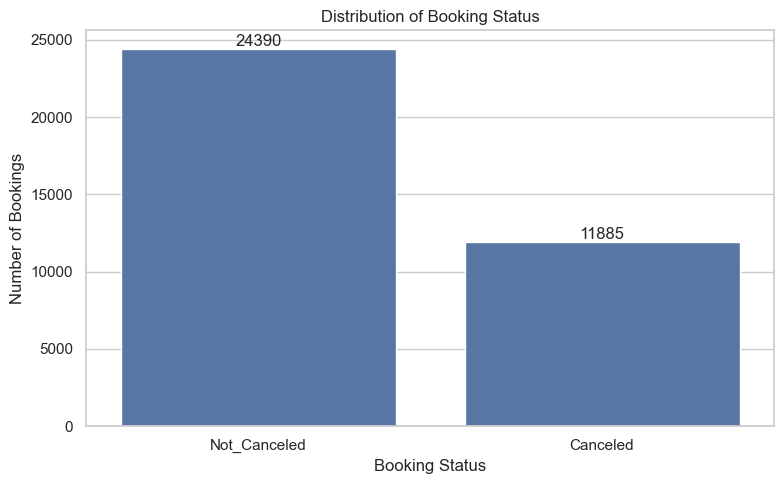

In [9]:
# TARGET DISTRIBUTION

target_percentage = (
    df["booking_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    target_percentage.to_frame("Percentage")
)
print()

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="booking_status"
)

plt.title("Distribution of Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [10]:
# IDENTIFYING FEATURE TYPES

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_features.remove("Booking_ID")
categorical_features.remove("booking_status")

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']

Categorical features:
['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']


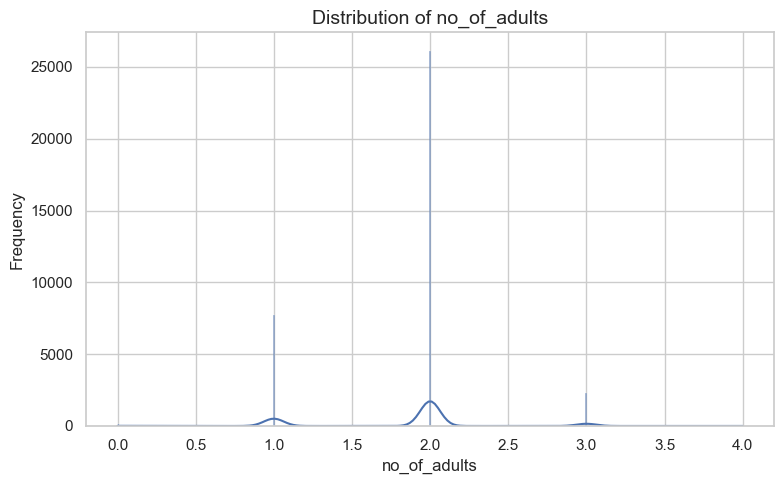

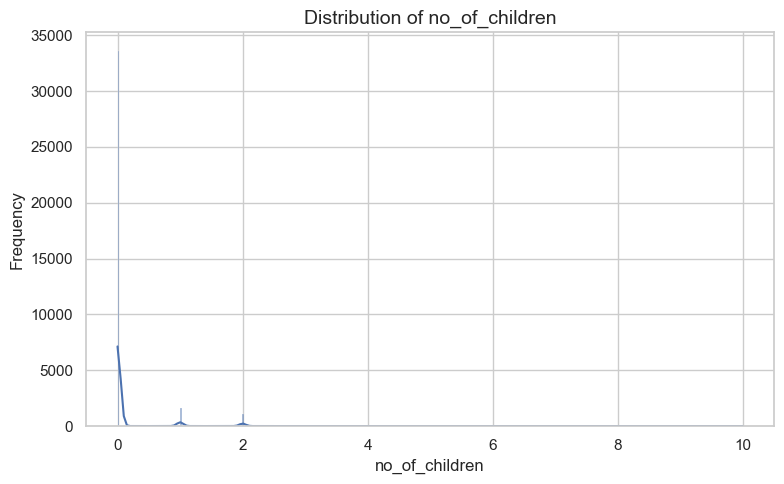

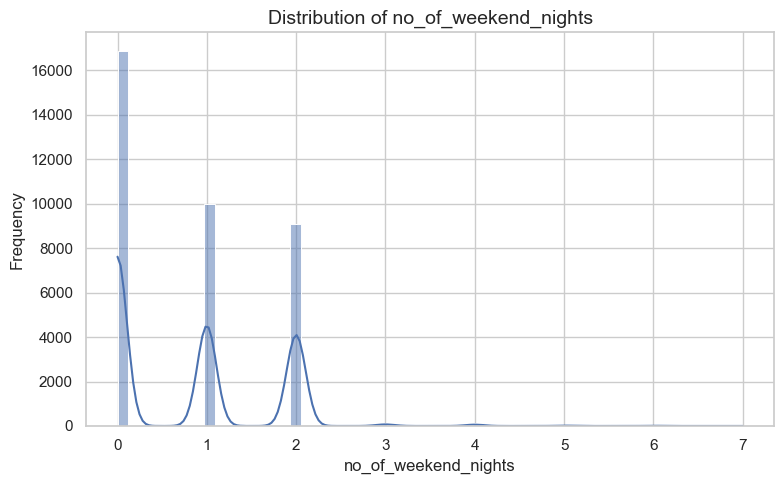

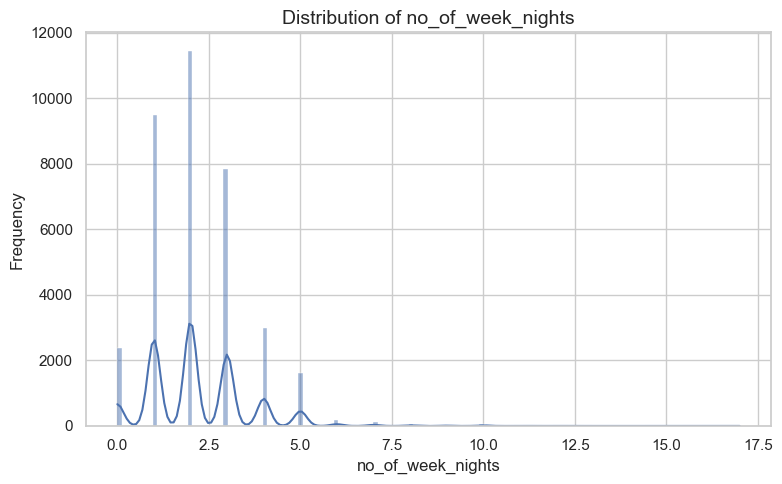

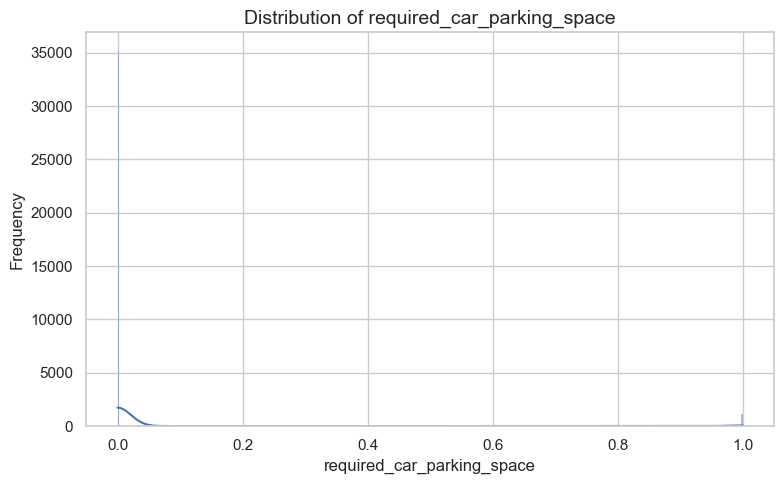

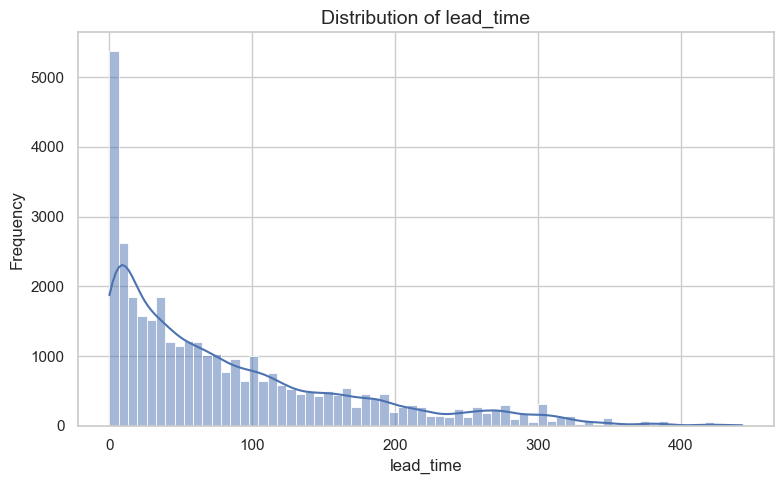

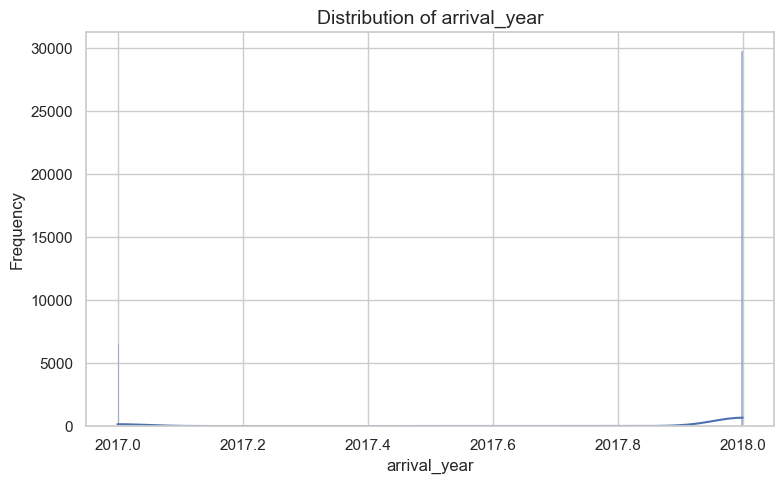

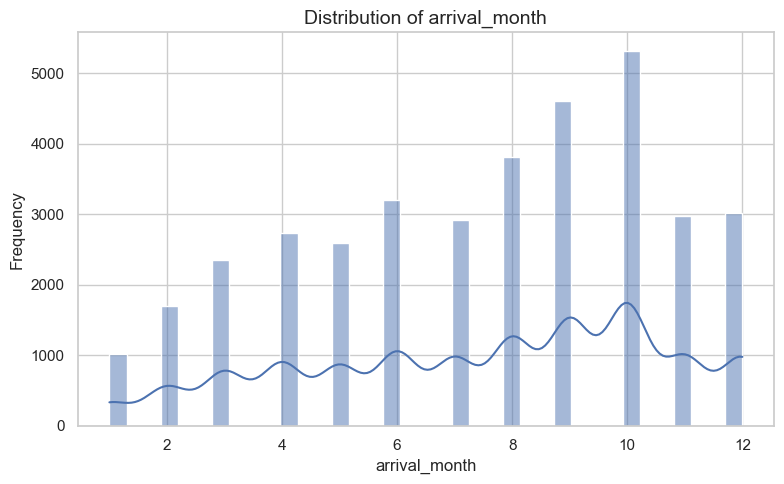

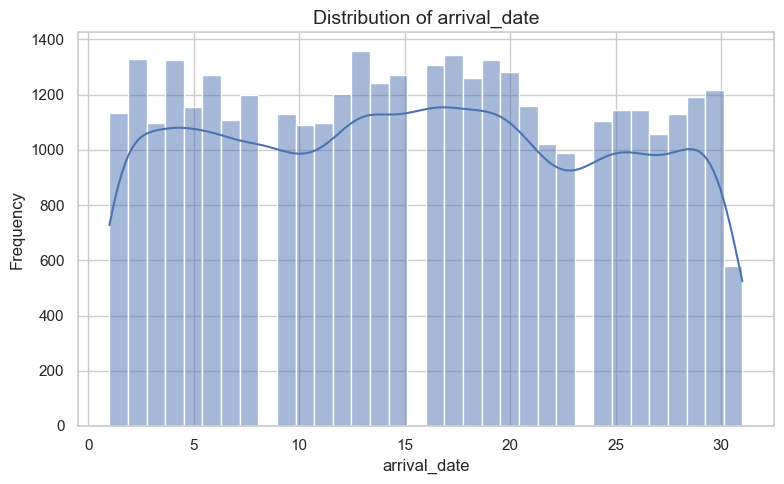

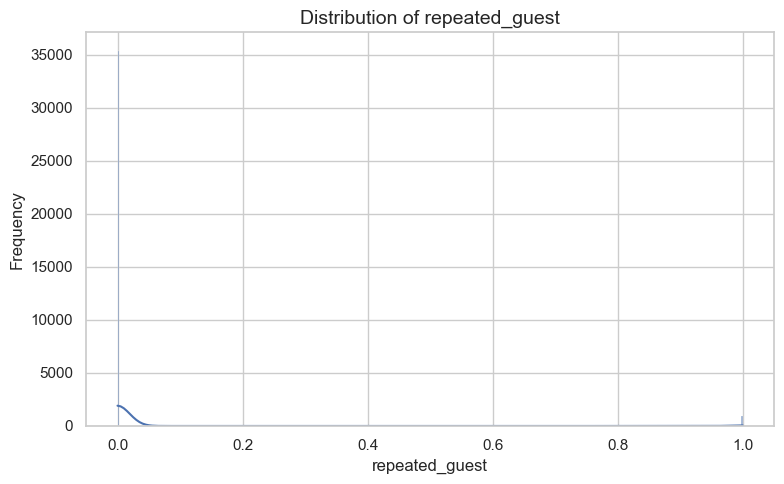

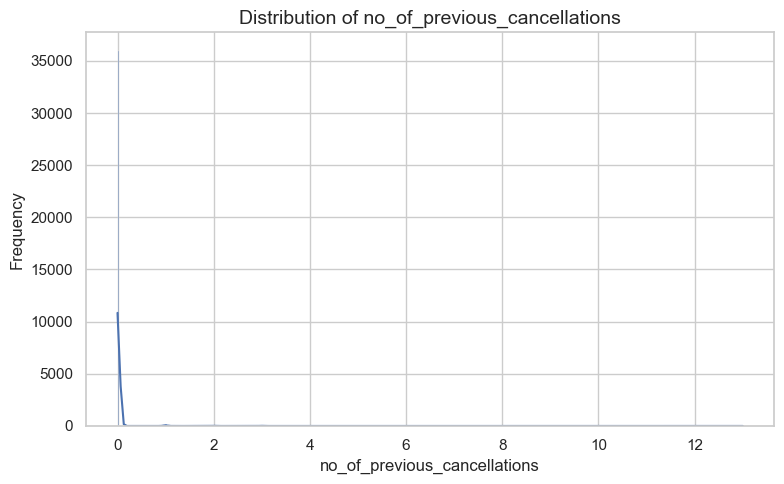

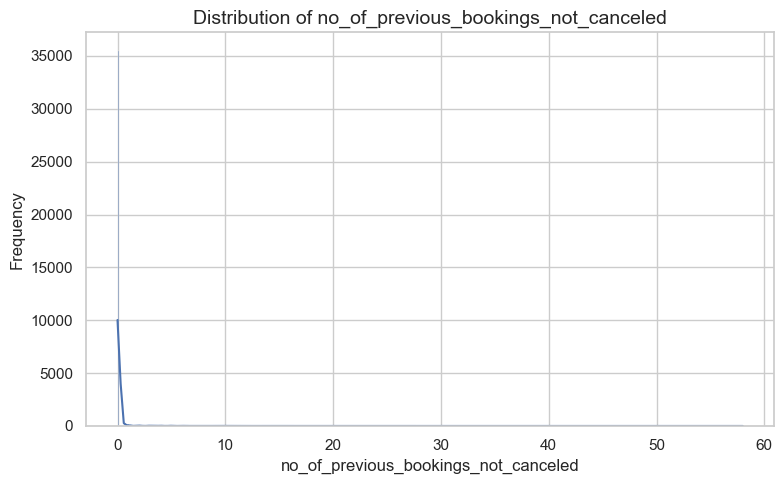

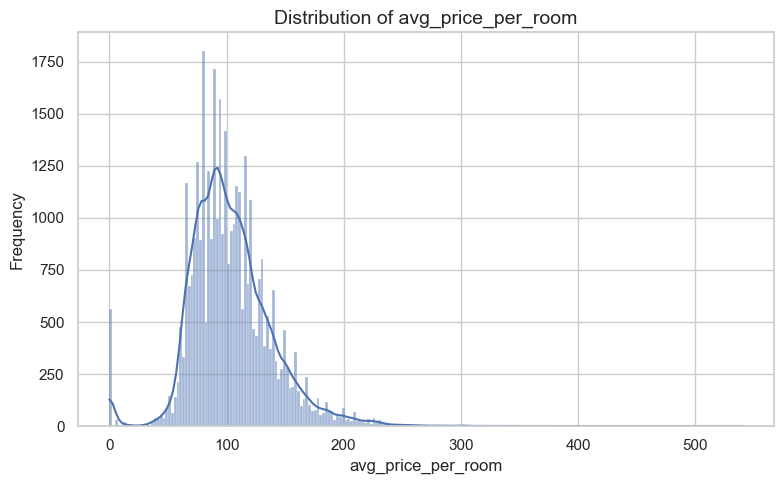

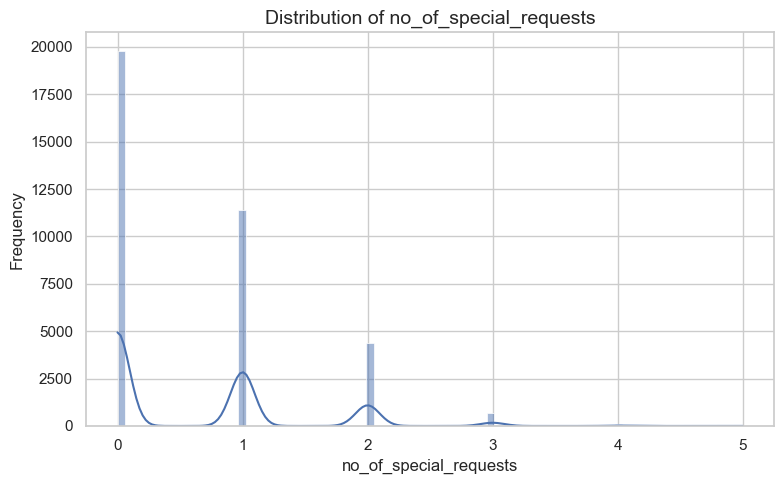

In [11]:
# NUMERICAL FEATURE DISTRIBUTIONS

for feature in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}", fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.tight_layout()
    plt.show()

### Observation – Numerical Feature Distributions

The numerical features exhibit different ranges and distribution shapes.
Some variables are concentrated within relatively narrow ranges, while
features such as `lead_time` show a wider spread.

The distributions of `lead_time` and `avg_price_per_room` also show
potential extreme observations. These observations are examined further
using boxplots and the IQR method before deciding how they should be
treated.

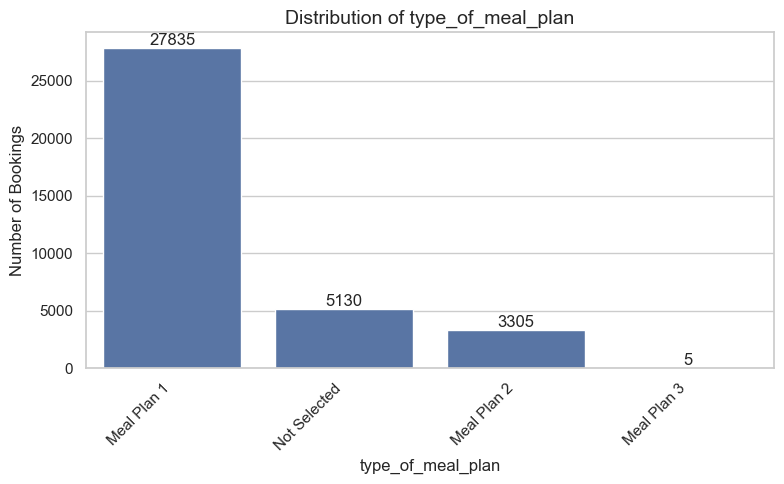

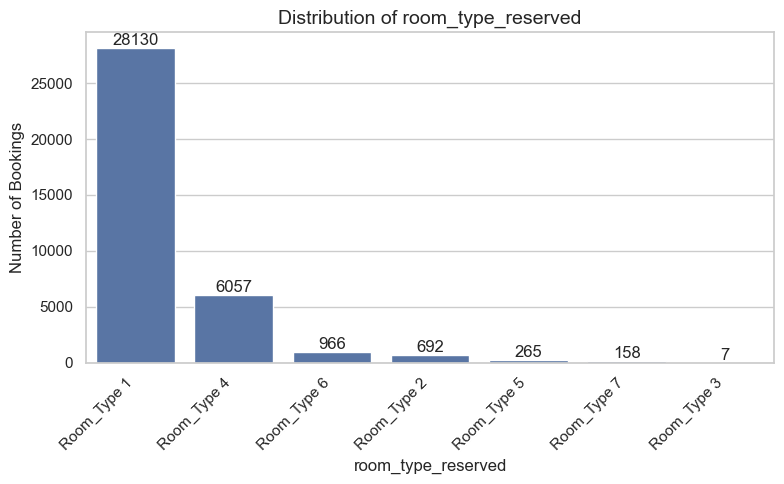

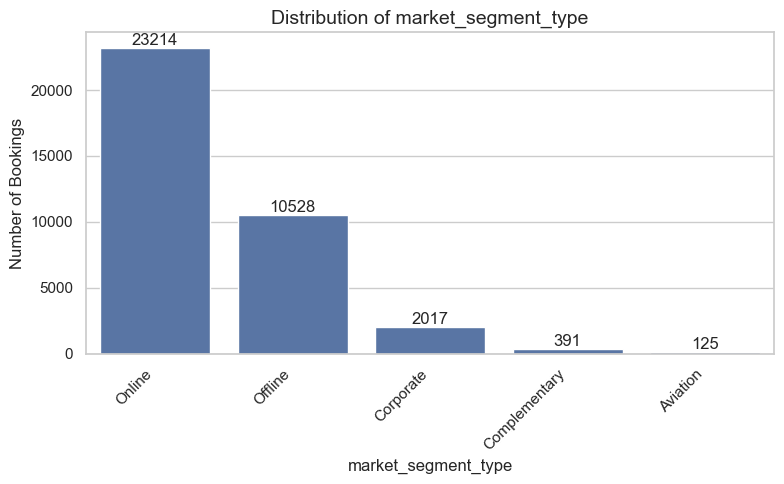

In [12]:
# CATEGORICAL FEATURE DISTRIBUTIONS

for feature in categorical_features:

    plt.figure(figsize=(8, 5))

    order = df[feature].value_counts().index

    ax = sns.countplot(
        data=df,
        x=feature,
        order=order
    )

    plt.title(f"Distribution of {feature}", fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Number of Bookings", fontsize=12)

    # Rotate labels when necessary
    plt.xticks(rotation=45, ha="right")

    # Add counts above bars
    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()

### Observation – Categorical Feature Distributions

The categorical variables contain multiple booking-related categories,
with some categories occurring more frequently than others.
The variation in category frequencies indicates that categorical
variables may provide useful information for predicting booking
cancellation. Since these variables are nominal categories, they are
converted into numerical representations using One-Hot Encoding during
preprocessing.

These distributions helps in identifing rare or dominant
categories before model training.

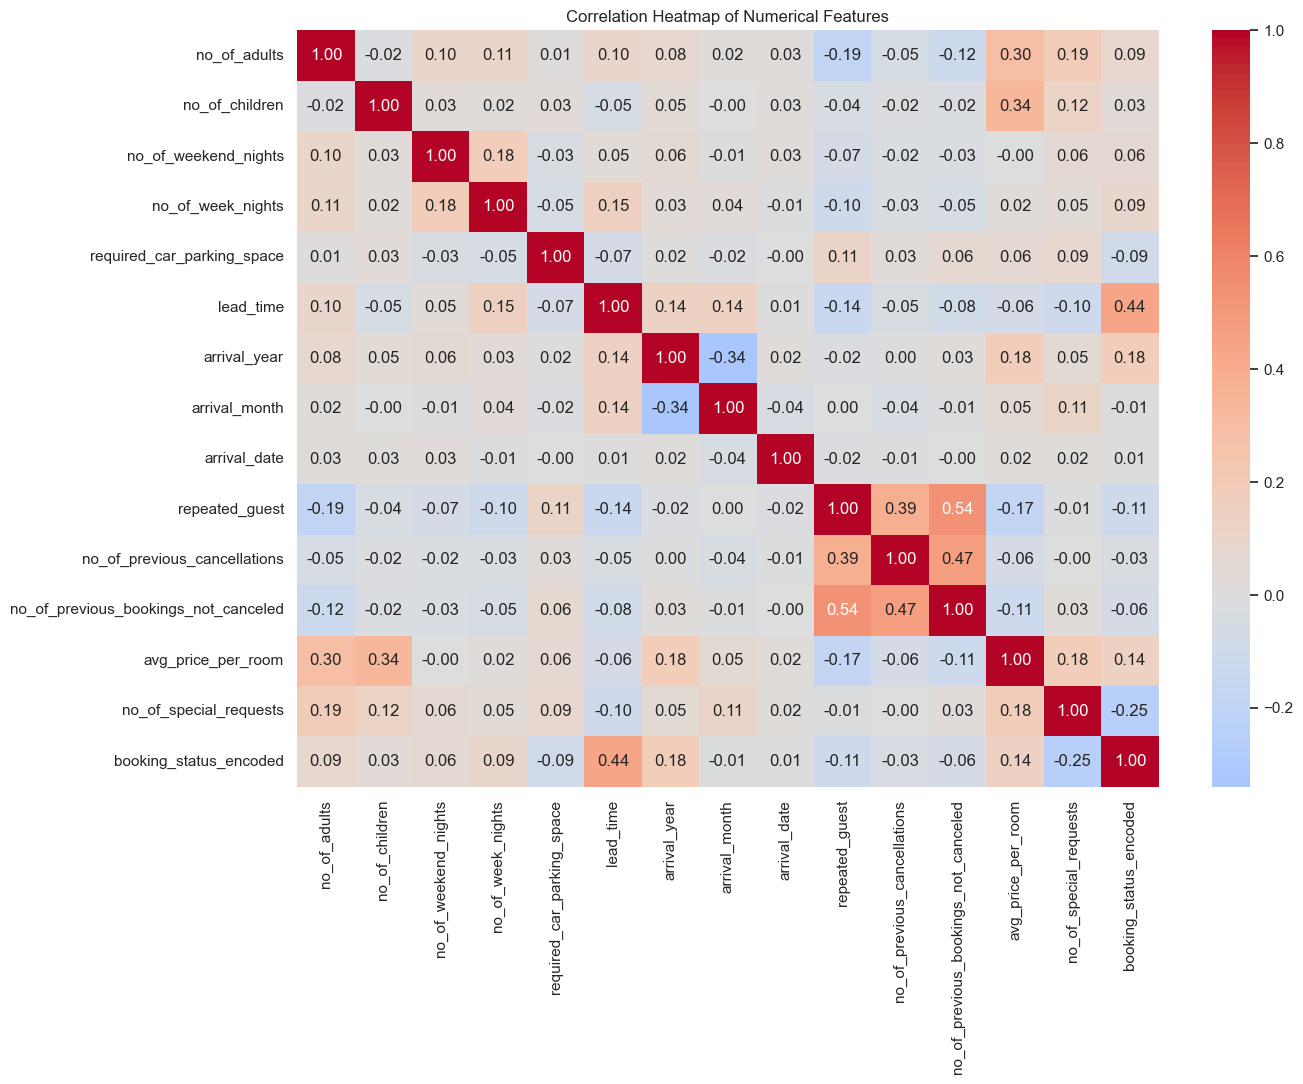

In [13]:
# ENCODING TARGET FOR CORRELATION ANALYSIS

df_corr = df.copy()

df_corr["booking_status_encoded"] = (
    df_corr["booking_status"]
    .map({
        "Not_Canceled": 0,
        "Canceled": 1
    })
)

correlation_features = numerical_features + [
    "booking_status_encoded"
]

correlation_matrix = df_corr[
    correlation_features
].corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Observation – Correlation Heatmap

The correlation heatmap shows the pairwise linear relationships between
the numerical features and the encoded target variable.

The heatmap indicates that `lead_time` has a noticeable positive
association with the cancellation target, while variables such as
`no_of_special_requests` show a negative association with cancellation.
Other feature pairs show weaker or moderate linear relationships.

Some booking-history variables are also related to one another, they describe different aspects of a guest's
previous booking behaviour.

The correlations are not strong enough to indicate that any single
numerical feature can independently determine the booking status.
Therefore, multiple features are retained for model training.

In [14]:
df_plot = df.copy()

df_plot["booking_status_encoded"] = (
    df_plot["booking_status"]
    .map({
        "Not_Canceled": 0,
        "Canceled": 1
    })
)

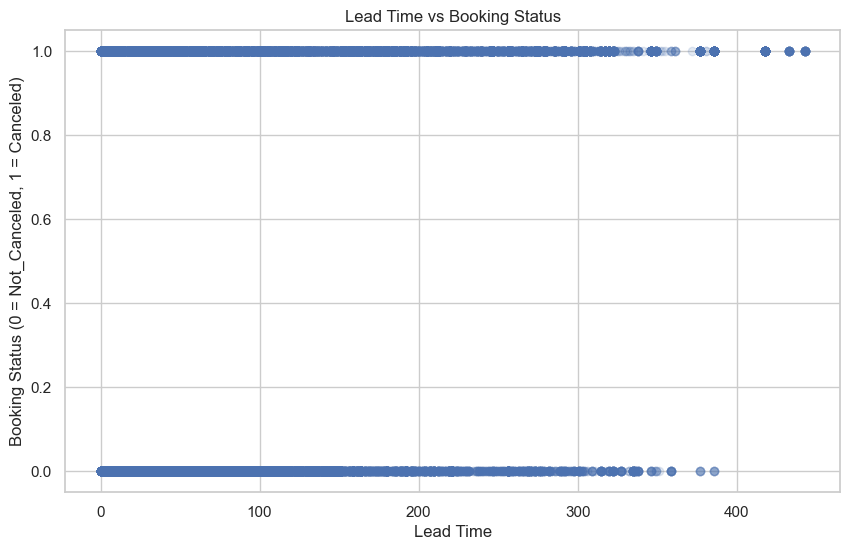

In [15]:
# LEAD TIME VS BOOKING STATUS
plt.figure(figsize=(10, 6))

plt.scatter(
    df_plot["lead_time"],
    df_plot["booking_status_encoded"],
    alpha=0.15
)

plt.title("Lead Time vs Booking Status")
plt.xlabel("Lead Time")
plt.ylabel("Booking Status (0 = Not_Canceled, 1 = Canceled)")

plt.show()

### Observation – Lead Time vs Booking Status

The scatter plot shows that both canceled and non-canceled bookings occur
across a wide range of lead times. The points form two horizontal bands because
the target variable is binary, with 0 representing Not_Canceled and 1
representing Canceled.

A greater concentration of canceled bookings can be observed at relatively
higher lead-time values, suggesting that lead time may contain useful
information for distinguishing between the two booking outcomes. However,
there is substantial overlap between the two classes, so lead time alone
cannot clearly separate canceled and non-canceled bookings.

A few observations occur at very high lead-time values. These are potential
extreme observations and should be investigated during the outlier analysis
rather than automatically removed.

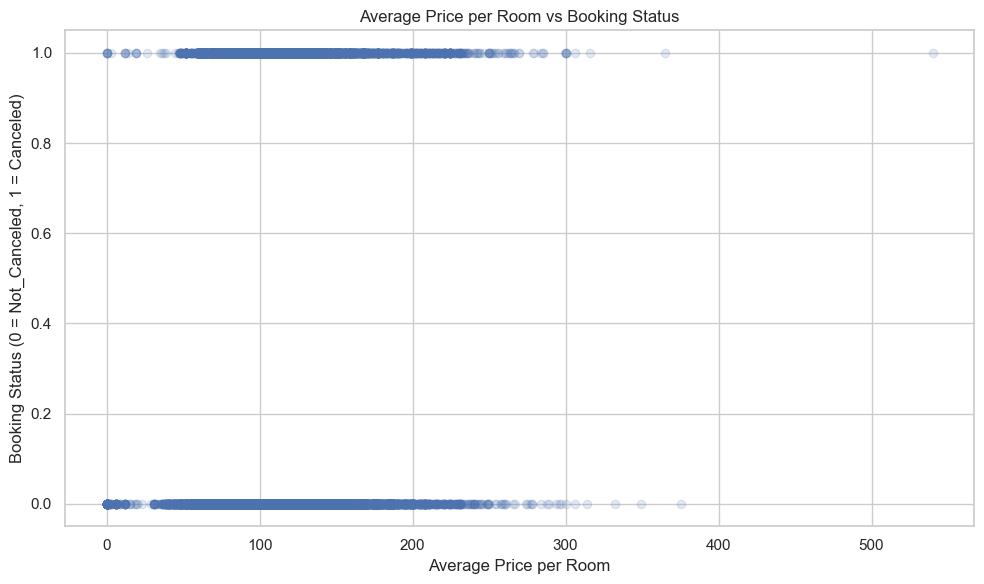

In [16]:
# AVERAGE PRICE PER ROOM VS BOOKING STATUS

plt.figure(figsize=(10, 6))

plt.scatter(
    df_plot["avg_price_per_room"],
    df_plot["booking_status_encoded"],
    alpha=0.15
)

plt.title("Average Price per Room vs Booking Status")
plt.xlabel("Average Price per Room")
plt.ylabel("Booking Status (0 = Not_Canceled, 1 = Canceled)")

plt.tight_layout()
plt.show()

### Observation – Average Price per Room vs Booking Status

The scatter plot shows that both canceled and non-canceled bookings occur across
a broad range of average room prices. The two classes overlap substantially,
particularly within the central range of room prices.

Therefore, average price per room does not appear to provide a clear separation
between the two booking outcomes when considered by itself. Nevertheless, the
feature may still contribute useful information when combined with other
booking characteristics in a machine learning model.

A small number of observations have unusually high room prices compared with
the majority of bookings. These observations should be examined as part of
the outlier analysis before deciding whether any treatment is necessary.

## Outlier Visualization Using Boxplots

Before performing numerical outlier detection, boxplots are used for
inspecting the distribution of numerical features.

A boxplot summarizes the distribution using the median, quartiles and
whiskers. Observations beyond the whiskers may indicate potential outliers.

These observations are not automatically considered errors. They will be
examined further using the Interquartile Range (IQR) method before deciding
whether any treatment should be performed.

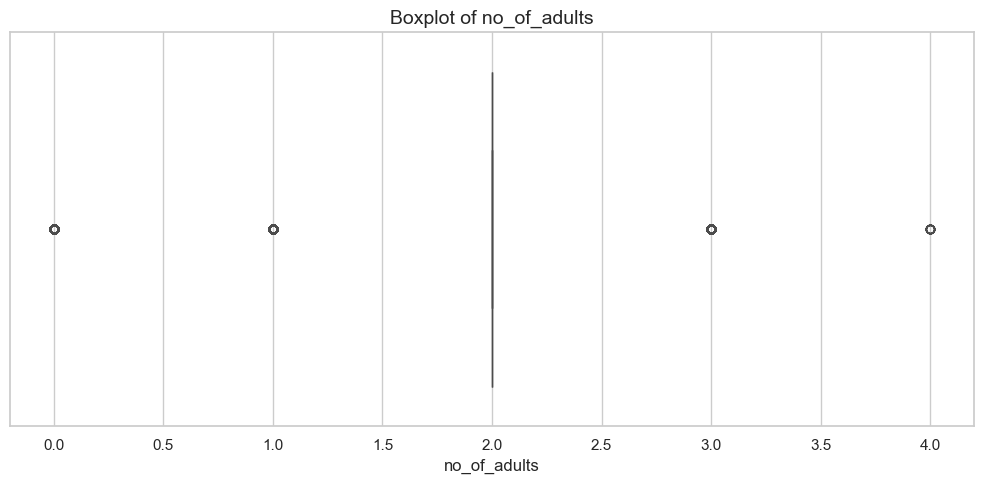

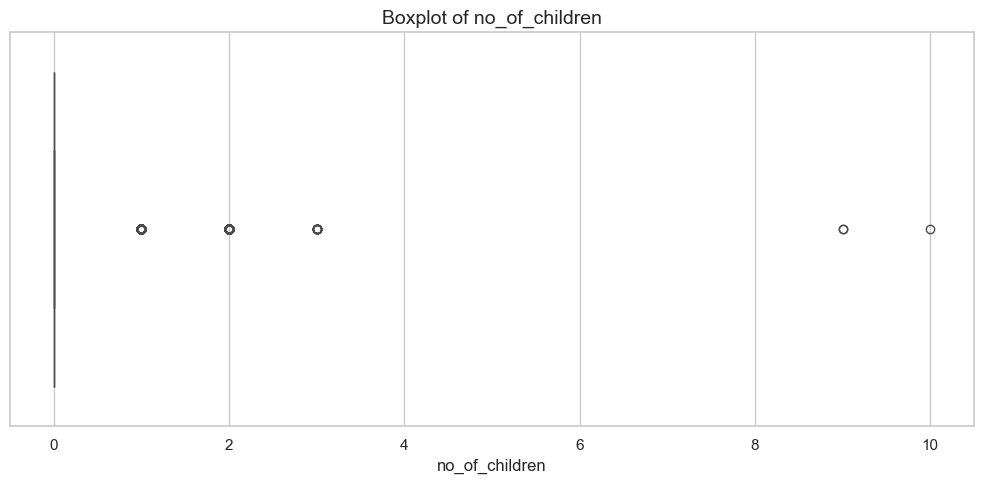

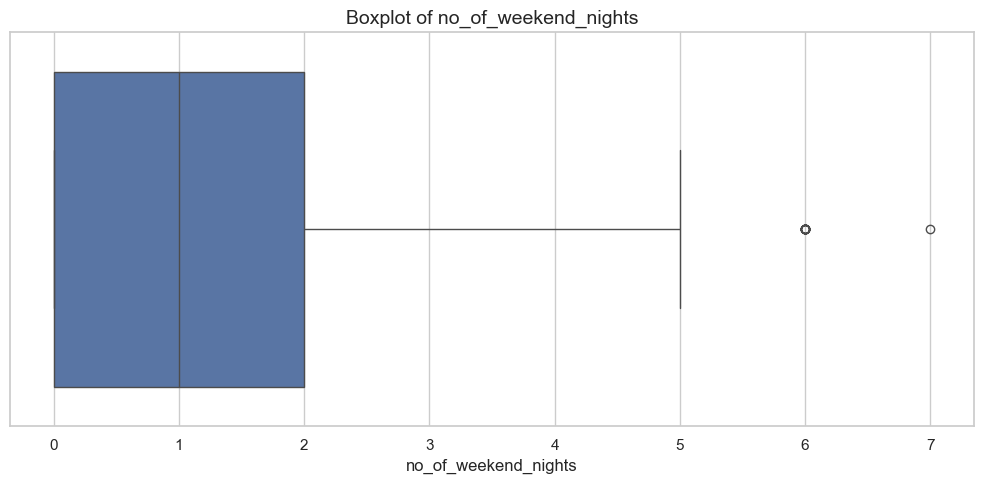

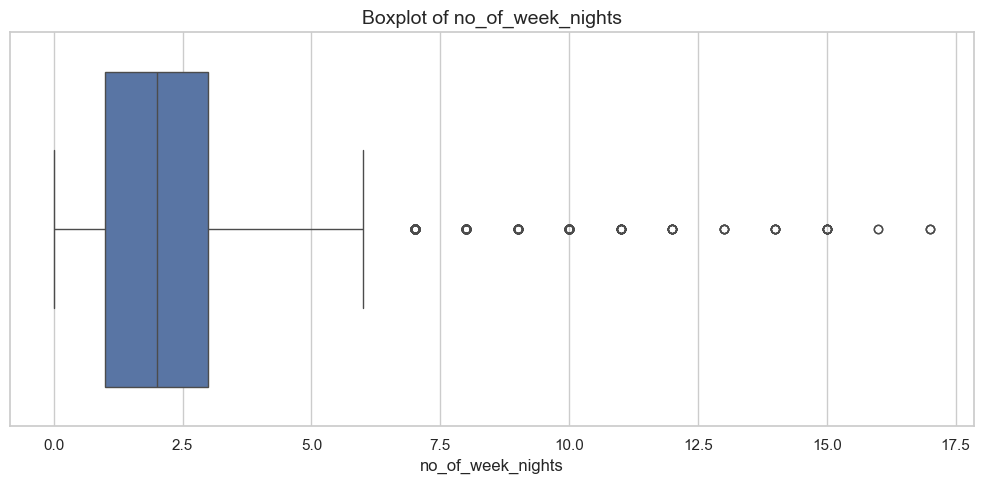

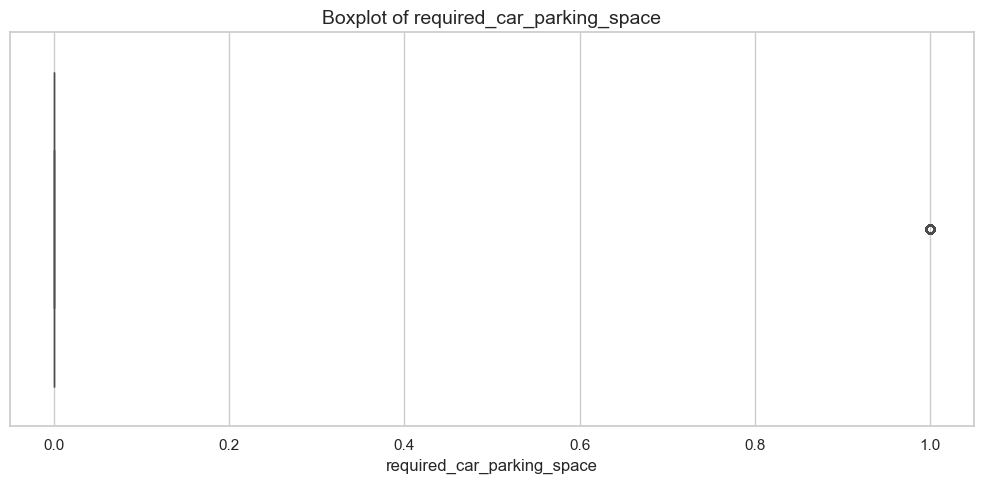

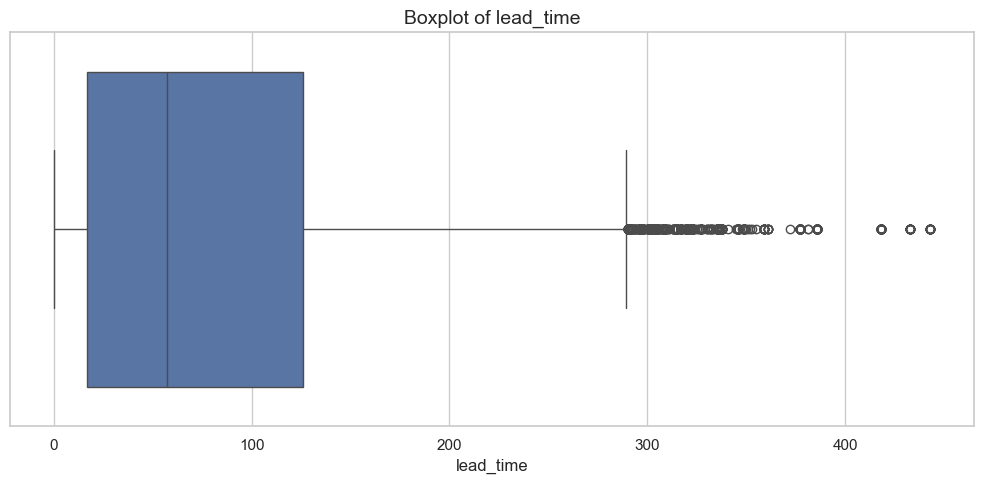

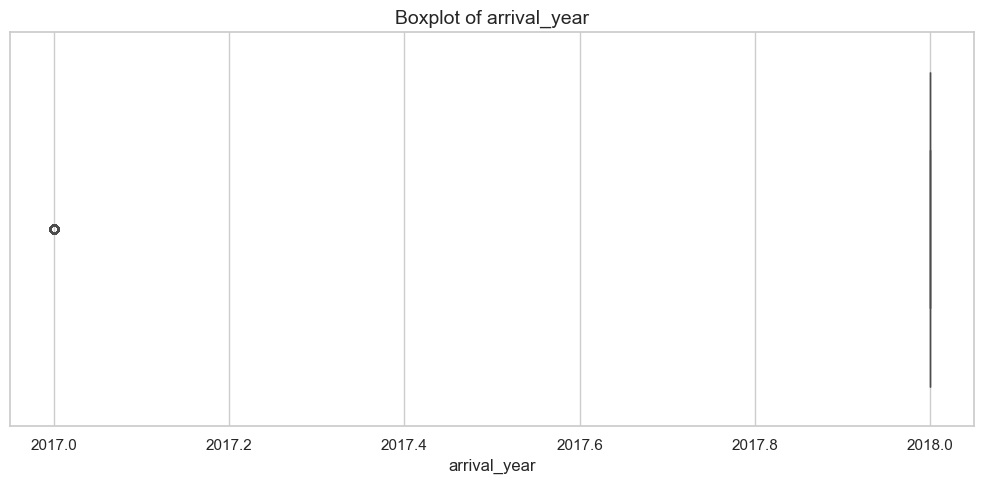

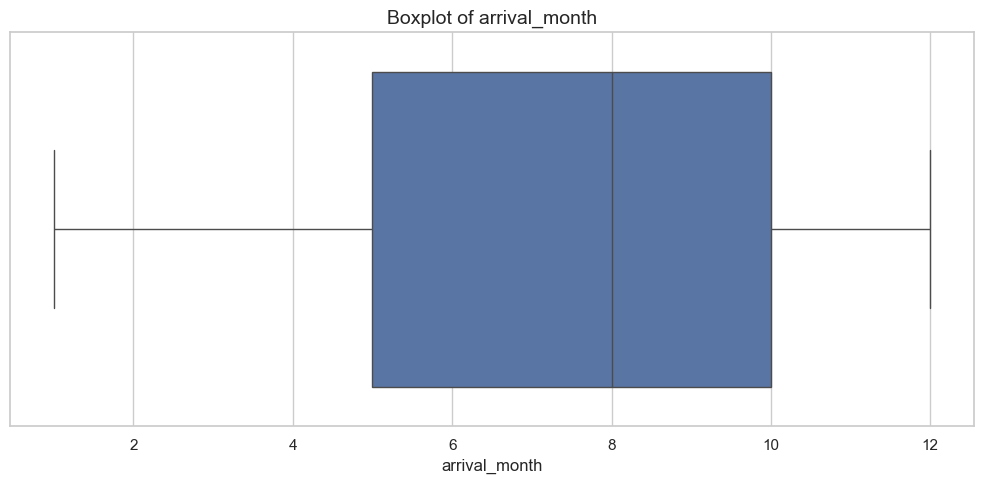

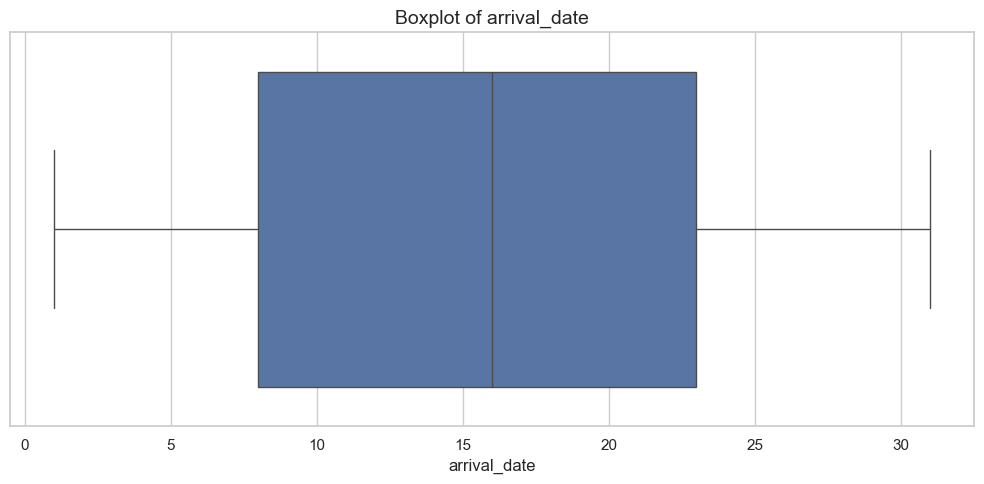

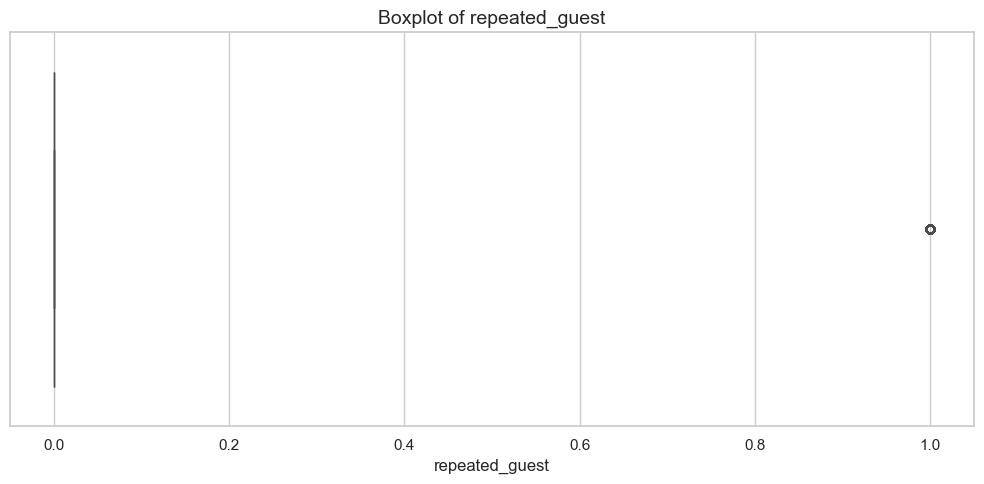

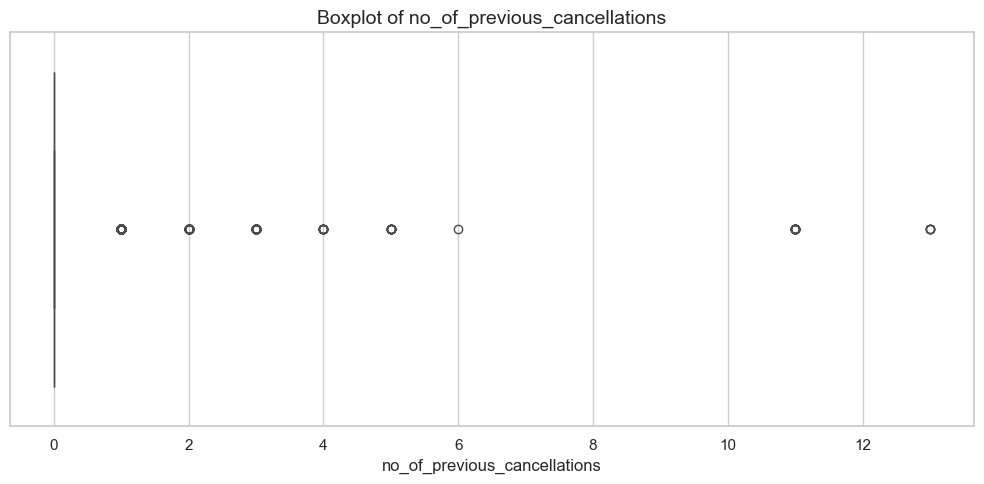

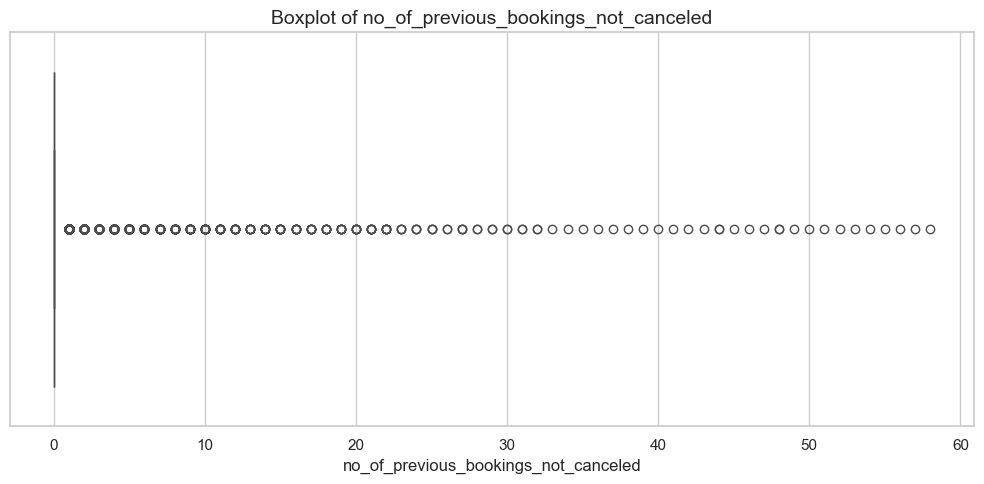

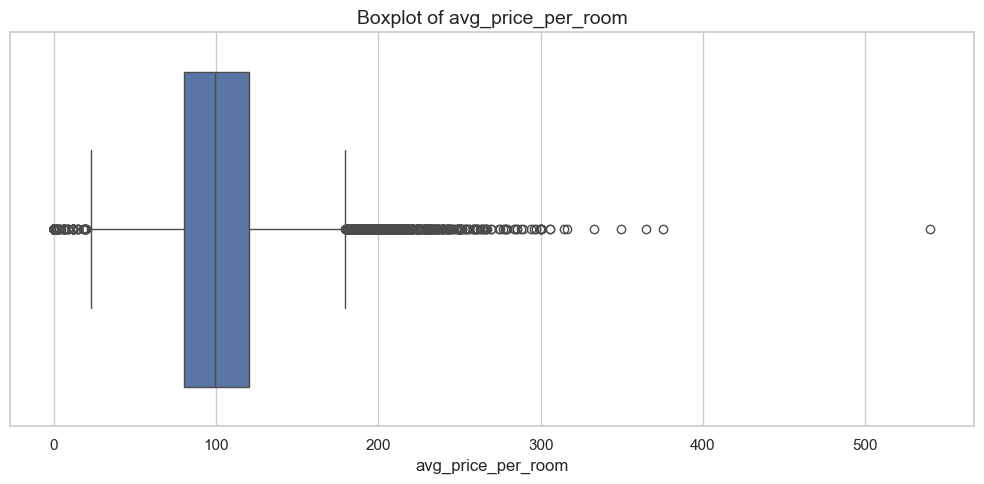

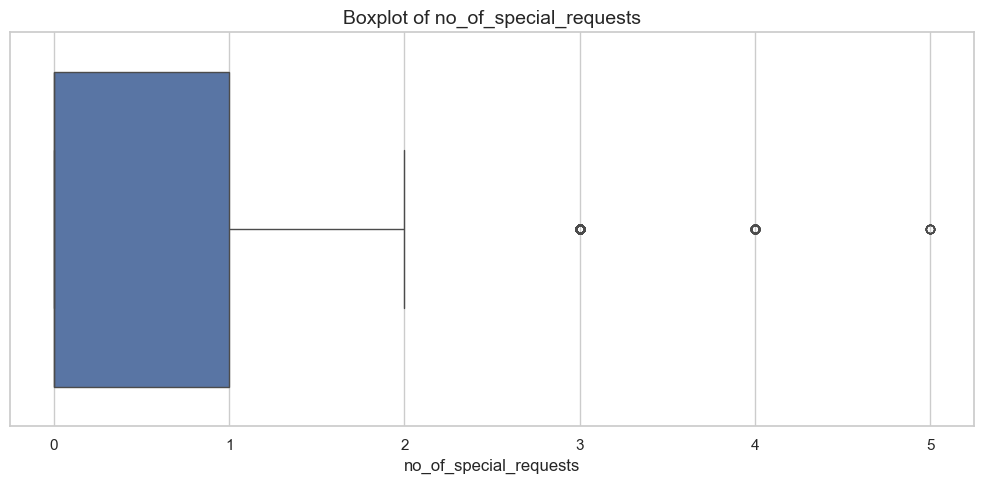

In [17]:
# BOXPLOTS FOR NUMERICAL FEATURES

for feature in numerical_features:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(
        f"Boxplot of {feature}",
        fontsize=14
    )

    plt.xlabel(
        feature,
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

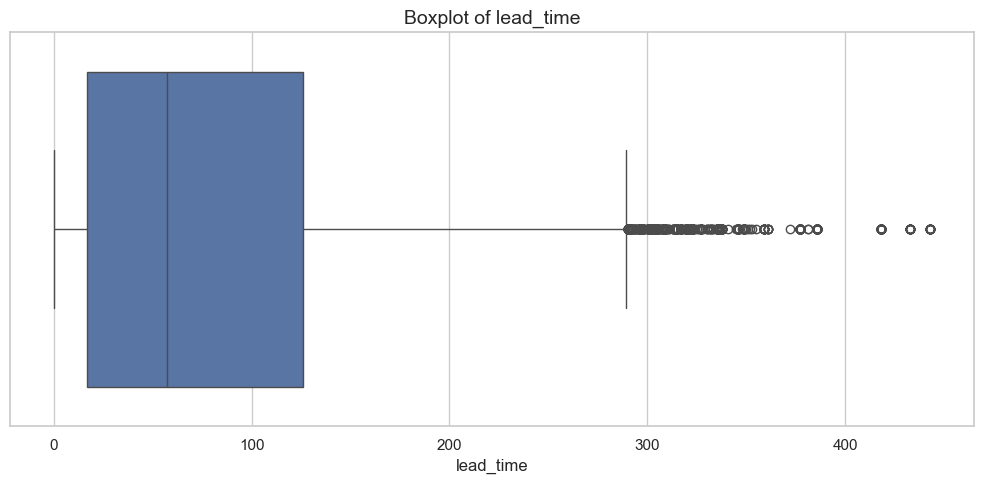

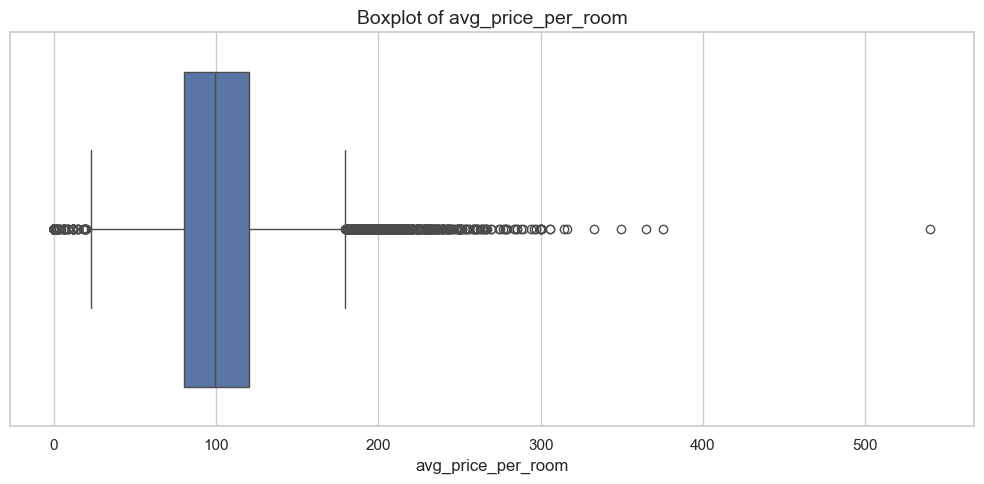

In [18]:
# BOX plots FOR CONTINUOUS FEATURES

continuous_features = [
    "lead_time",
    "avg_price_per_room"
]

for feature in continuous_features:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df[feature]
    )

    plt.title(
        f"Boxplot of {feature}",
        fontsize=14
    )

    plt.xlabel(
        feature,
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

In [19]:
# OUTLIER DETECTION USING IQR

outlier_summary = []

for feature in continuous_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier %": len(outliers) / len(df) * 100
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,lead_time,17.0,126.0,-146.50,289.50,1331,3.669194
1,avg_price_per_room,80.3,120.0,20.75,179.55,1696,4.675396


## Data Cleaning and Preparation

Based on the dataset audit, no missing values or duplicate records are
present. Therefore, no missing-value imputation or duplicate removal is
required.

The exploratory boxplots and IQR analysis identified potential extreme
observations in the continuous numerical features. These observations are
not automatically considered erroneous because unusually high values can
represent legitimate hotel bookings.

To avoid unnecessarily removing valid observations, an IQR-based capping
strategy is used for the selected continuous features.

The final outlier-treatment thresholds will be calculated using the training
data only after the stratified train-test split. The same training-derived
thresholds will then be applied to both the training and test sets. This
prevents information from the test set from influencing preprocessing.

## Feature Engineering

Feature engineering is performed to create informative representations from
the original booking attributes.

The following features are created:

- **total_nights:** Sum of weekend and weekday nights. This represents the
  overall length of stay using a single feature.

- **total_guests:** Sum of adults and children. This represents the total
  number of guests associated with the booking.

- **total_previous_bookings:** Sum of previous cancellations and previous
  non-canceled bookings. This provides an overall measure of the customer's
  historical booking activity.

- **is_family:** Binary feature indicating whether children are included in
  the booking. This may capture differences in booking patterns between
  family and non-family reservations.

- **price_per_guest:** Average room price normalized by the number of guests.
  This provides a measure of the room price relative to booking party size.

- **arrival_month_sin and arrival_month_cos:** Cyclic transformations of
  arrival month. These preserve the circular nature of calendar months, where
  December and January are adjacent.

These engineered features are intended to provide the classification models
with additional representations that may help capture relationships in the
booking data.

In [20]:
# FEATURE ENGINEERING

data = df.copy()

# Total number of nights
data["total_nights"] = (
    data["no_of_weekend_nights"] +
    data["no_of_week_nights"]
)

# Total number of guests
data["total_guests"] = (
    data["no_of_adults"] +
    data["no_of_children"]
)

# Total historical booking activity
data["total_previous_bookings"] = (
    data["no_of_previous_cancellations"] +
    data["no_of_previous_bookings_not_canceled"]
)

# Whether the booking includes children
data["is_family"] = (
    data["no_of_children"] > 0
).astype(int)

# Average price per guest
data["price_per_guest"] = (
    data["avg_price_per_room"] /
    data["total_guests"].replace(0, np.nan)
)

# Cyclic encoding of arrival month
data["arrival_month_sin"] = np.sin(
    2 * np.pi * data["arrival_month"] / 12
)

data["arrival_month_cos"] = np.cos(
    2 * np.pi * data["arrival_month"] / 12
)

print("Feature engineering completed.")
print("New shape:", data.shape)

Feature engineering completed.
New shape: (36275, 26)


In [21]:
# FEATURE AND TARGET SEPARATION

# 'data' contains the cleaned and engineered dataset

print("Target values before encoding:")
print(data["booking_status"].value_counts(dropna=False))

data["booking_status"] = data["booking_status"].replace({
    "Not_Canceled": 0,
    "Canceled": 1
})

print("\nTarget values after encoding:")
print(data["booking_status"].value_counts(dropna=False))

# Dropping booking_id because it is just an identifier for the booking and not a meaningful characteristic of the booking and also the target column
X = data.drop(
    columns=["Booking_ID", "booking_status"]
)

y = data["booking_status"]

print("\nFeature matrix shape :", X.shape)
print("Target shape         :", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target values before encoding:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

Target values after encoding:
booking_status
0    24390
1    11885
Name: count, dtype: int64

Feature matrix shape : (36275, 24)
Target shape         : (36275,)

Target distribution:
booking_status
0    24390
1    11885
Name: count, dtype: int64

Target proportions:
booking_status
0    67.24
1    32.76
Name: proportion, dtype: float64


In [22]:
print("Unique target values after mapping:")
print(data["booking_status"].unique())

print("\nNumber of NaN values in target:")
print(data["booking_status"].isna().sum())

print("\nOriginal target values:")
print(df["booking_status"].value_counts(dropna=False))

Unique target values after mapping:
[0 1]

Number of NaN values in target:
0

Original target values:
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


In [23]:
# STRATIFIED TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape :", X_train.shape)
print("Testing set shape  :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape : (29020, 24)
Testing set shape  : (7255, 24)

Training target distribution:
booking_status
0    19512
1     9508
Name: count, dtype: int64

Testing target distribution:
booking_status
0    4878
1    2377
Name: count, dtype: int64


## Outlier Treatment – IQR Capping

From the analysis above identified potential outliers in `lead_time` and
`avg_price_per_room`.

Instead of removing these observations, IQR capping is applied
to retain potentially valid booking records while reducing the
influence of extreme values.

To prevent data leakage, the IQR thresholds are calculated
using only the training data and then applied to both the
training and testing sets.

In [24]:
# TRAIN-ONLY IQR OUTLIER CAPPING

X_train = X_train.copy()
X_test = X_test.copy()

iqr_limits = {}

for col in continuous_features:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    iqr_limits[col] = (lower_bound, upper_bound)
    
    # Apply the training-derived limits to both datasets
    X_train[col] = X_train[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )
    
    X_test[col] = X_test[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("IQR capping completed.")
print("\nTraining-derived IQR limits:")

for col, (lower, upper) in iqr_limits.items():
    print(f"{col}:")
    print(f"  Lower bound = {lower:.2f}")
    print(f"  Upper bound = {upper:.2f}")

print("\nShapes after outlier treatment:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

IQR capping completed.

Training-derived IQR limits:
lead_time:
  Lower bound = -148.00
  Upper bound = 292.00
avg_price_per_room:
  Lower bound = 20.75
  Upper bound = 179.55

Shapes after outlier treatment:
X_train: (29020, 24)
X_test : (7255, 24)


## Data Preprocessing

The dataset contains both numerical and categorical features.

Numerical features are handled using median imputation and scaling,
while categorical features are handled using most-frequent imputation
and one-hot encoding.

All preprocessing operations are fitted only on the training data
and then applied to both the training and testing sets to prevent
data leakage.

Separate preprocessing pipelines are prepared because scaling is
important for distance and margin-based algorithms such as Logistic
Regression, KNN and SVC, whereas Decision Tree does not require
feature scaling.

In [25]:
# IDENTIFYING NUMERICAL AND CATEGORICAL FEATURES

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 21
Number of categorical features: 3

Numerical features:
['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'total_nights', 'total_guests', 'total_previous_bookings', 'is_family', 'price_per_guest', 'arrival_month_sin', 'arrival_month_cos']

Categorical features:
['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']


### Preprocessing Pipelines

Two preprocessing pipelines are created for the classification models.

**Scaled preprocessing**
- Numerical features → median imputation → StandardScaler
- Categorical features → most-frequent imputation → One-Hot Encoding

This preprocessing is used for Logistic Regression, KNN, and SVC because
these algorithms are sensitive to feature scale.

**Unscaled preprocessing**
- Numerical features → median imputation
- Categorical features → most-frequent imputation → One-Hot Encoding

This preprocessing is used for Gaussian Naive Bayes and Decision Tree.

Gaussian Naive Bayes does not require standardized numerical features
because it estimates a Gaussian distribution for each feature and class.
Decision Trees are also not sensitive to the scale of numerical features.

All preprocessing operations are placed inside model pipelines so that
the preprocessing parameters are learned from the training data during
model fitting and are not fitted using the held-out test set.

In [26]:
# PREPROCESSING PIPELINES

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing for scaled models

numeric_transformer_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Numerical preprocessing for Decision Tree

numeric_transformer_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing

categorical_transformer_scaled = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

categorical_transformer_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

# Preprocessor for scaled algorithms

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_scaled,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer_scaled,
            categorical_features
        )
    ]
)

# Preprocessor for Decision Tree

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_tree,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer_tree,
            categorical_features
        )
    ]
)

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


## 1. Logistic Regression

Logistic Regression is used as the baseline classification model for
predicting hotel booking cancellation.

The model is evaluated using Accuracy, Precision, Recall,
Weighted F1-score, ROC-AUC and a Confusion Matrix.

In [27]:
# LOGISTIC REGRESSION - IMPORTS

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Logistic Regression libraries imported successfully.")

Logistic Regression libraries imported successfully.


In [28]:
# LOGISTIC REGRESSION PIPELINE

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


### Model Training

The Logistic Regression model is trained using the training set.
The test set is kept completely separate for final evaluation.

In [29]:
# TRAIN LOGISTIC REGRESSION

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [30]:
# LOGISTIC REGRESSION PREDICTIONS

y_pred_lr = logistic_model.predict(X_test)

# Probability of the positive class (Canceled)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_lr))

Predictions generated successfully.
Number of predictions: 7255


### Logistic Regression Evaluation

The model is evaluated on the unseen testing set using multiple
classification metrics.

In [31]:
# LOGISTIC REGRESSION - EVALUATION

lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    zero_division=0
)

lr_f1_weighted = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_roc_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print("Logistic Regression Performance")
print("\n")
print(f"Accuracy       : {lr_accuracy:.4f}")
print(f"Precision      : {lr_precision:.4f}")
print(f"Recall         : {lr_recall:.4f}")
print(f"Weighted F1    : {lr_f1_weighted:.4f}")
print(f"ROC-AUC        : {lr_roc_auc:.4f}")

Logistic Regression Performance


Accuracy       : 0.8128
Precision      : 0.7519
Recall         : 0.6399
Weighted F1    : 0.8086
ROC-AUC        : 0.8716


In [32]:
# CLASSIFICATION REPORT

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Not_Canceled", "Canceled"],
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

Not_Canceled       0.84      0.90      0.87      4878
    Canceled       0.75      0.64      0.69      2377

    accuracy                           0.81      7255
   macro avg       0.79      0.77      0.78      7255
weighted avg       0.81      0.81      0.81      7255



### Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly
classified bookings for each class.

The classes are:
- Not_Canceled
- Canceled

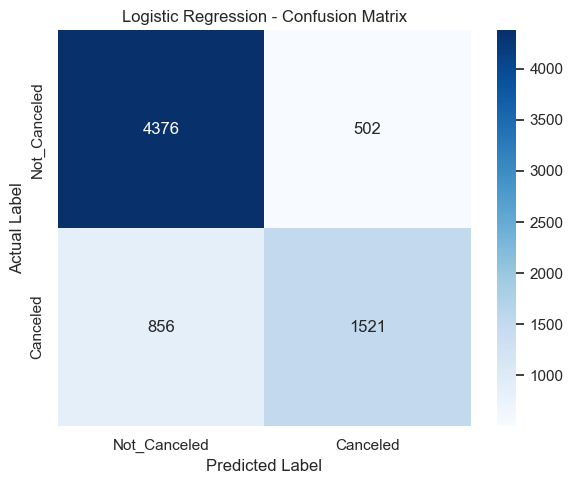

In [33]:
# LOGISTIC REGRESSION - CONFUSION MATRIX

import matplotlib.pyplot as plt
import seaborn as sns

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not_Canceled", "Canceled"],
    yticklabels=["Not_Canceled", "Canceled"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### Observation – Logistic Regression

Logistic Regression achieved an accuracy of 81.28% and a weighted
F1-score of 80.86% on the unseen test set. The ROC-AUC of 87.16%
indicates that the model has useful discriminatory ability between
canceled and non-canceled bookings.

The classification report shows stronger performance for the
Not_Canceled class than for the Canceled class. In particular, the
recall for Canceled bookings is lower than the recall for
Not_Canceled bookings, indicating that some canceled bookings are
not identified by the model.

In [34]:
# STORE LOGISTIC REGRESSION RESULTS

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "Weighted F1": lr_f1_weighted,
    "ROC-AUC": lr_roc_auc
})

print("Logistic Regression results stored.")

Logistic Regression results stored.


In [35]:
# LOGISTIC REGRESSION - COEFFICIENTS

# Get the fitted preprocessing component
fitted_preprocessor = logistic_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

coefficient_df.head(15)

,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
33,cat__market_segment_type_Complementary,-1.746439,0.174394,1.746439
5,num__lead_time,1.298419,3.663501,1.298419
13,num__no_of_special_requests,-1.149657,0.316745,1.149657
32,cat__market_segment_type_Aviation,1.037744,2.822842,1.037744
35,cat__market_segment_type_Offline,-0.931691,0.393887,0.931691
36,cat__market_segment_type_Online,0.802267,2.230592,0.802267
12,num__avg_price_per_room,0.557631,1.746530,0.557631
31,cat__room_type_reserved_Room_Type 7,-0.555592,0.573732,0.555592
21,cat__type_of_meal_plan_Meal Plan 1,-0.524441,0.591886,0.524441
29,cat__room_type_reserved_Room_Type 5,-0.476060,0.621226,0.476060


### Interpretation – Logistic Regression Coefficients

The coefficient analysis identifies the features that have the strongest
association with the predicted cancellation odds.

`lead_time` has a strong positive coefficient. This means that, holding
the other model features constant, an increase in standardized
`lead_time` is associated with higher modeled odds of cancellation.

`no_of_special_requests` has a strong negative coefficient. Therefore,
an increase in this standardized feature is associated with lower modeled
odds of cancellation, holding the other features constant.

The odds-ratio column provides the corresponding multiplicative change
in modeled odds. For example, the odds ratio for `lead_time` is
approximately **3.66**, meaning that a one-standard-deviation increase
in `lead_time` corresponds to approximately 3.66 times the modeled
cancellation odds, with the other features held constant.

These are model-based associations rather than causal relationships.
The coefficients should therefore be interpreted as relationships
learned by the Logistic Regression model from the available data.

## 2. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a distance-based classification
algorithm that predicts the class of a new observation based on the
classes of its nearest training observations.

The value of k determines the number of neighboring observations
considered during prediction.

A small value of k can make the model sensitive to individual
observations, while a larger value of k generally produces a smoother
decision boundary.

Different values of k are evaluated on the training data to identify
a suitable value without using the test set for model selection.

In [36]:
# KNN - IMPORTS

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

print("KNN libraries imported successfully.")

KNN libraries imported successfully.


### KNN Hyperparameter Tuning

The number of neighbors (k) is tuned using 5-fold cross-validation
on the training set.

The test set is not used during hyperparameter selection.

Values of k = 3, 5, 7, 9 and 11 are evaluated using weighted F1-score
as the selection criterion because the target classes are not perfectly
balanced.

In [37]:
# KNN - TUNE k USING 5-FOLD CROSS-VALIDATION

k_values = [3, 5, 7, 9, 11]

knn_cv_results = []

for k in k_values:

    knn_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=k,
                    metric="minkowski",
                    p=2
                )
            )
        ]
    )

    cv_scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )

    knn_cv_results.append({
        "k": k,
        "Mean Weighted F1": cv_scores.mean(),
        "Std Weighted F1": cv_scores.std()
    })

knn_cv_results_df = pd.DataFrame(knn_cv_results)

display(knn_cv_results_df)

,k,Mean Weighted F1,Std Weighted F1
0,3,0.839405,0.003545
1,5,0.842438,0.002211
2,7,0.841205,0.004140
3,9,0.843015,0.004034
4,11,0.842060,0.003593


In [38]:
# SELECTING BEST 'k'

best_k = knn_cv_results_df.loc[
    knn_cv_results_df["Mean Weighted F1"].idxmax(),
    "k"
]

best_knn_cv_score = knn_cv_results_df.loc[
    knn_cv_results_df["Mean Weighted F1"].idxmax(),
    "Mean Weighted F1"
]

print("Best k:", int(best_k))
print(f"Best mean CV Weighted F1: {best_knn_cv_score:.4f}")

Best k: 9
Best mean CV Weighted F1: 0.8430


In [39]:
# FINAL KNN MODEL

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=int(best_k),
                metric="minkowski",
                p=2
            )
        )
    ]
)

knn_model.fit(X_train, y_train)

print(f"Final KNN model trained successfully with k = {int(best_k)}.")

Final KNN model trained successfully with k = 9.


In [40]:
# KNN PREDICTIONS

y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

print("KNN predictions generated successfully.")

KNN predictions generated successfully.


In [41]:
# KNN EVALUATION METRICS

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn, average="weighted")
knn_roc_auc = roc_auc_score(y_test, y_proba_knn)

print(f"Accuracy:           {knn_accuracy:.4f}")
print(f"Precision:          {knn_precision:.4f}")
print(f"Recall:             {knn_recall:.4f}")
print(f"Weighted F1-score:  {knn_f1:.4f}")
print(f"ROC-AUC:            {knn_roc_auc:.4f}")

Accuracy:           0.8520
Precision:          0.7987
Recall:             0.7329
Weighted F1-score:  0.8502
ROC-AUC:            0.9100


In [42]:
# CLASSIFICATION REPORT
print("KNN Classification Report")
print("\n")

print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=["Not_Canceled", "Canceled"]
    )
)

KNN Classification Report


              precision    recall  f1-score   support

Not_Canceled       0.87      0.91      0.89      4878
    Canceled       0.80      0.73      0.76      2377

    accuracy                           0.85      7255
   macro avg       0.84      0.82      0.83      7255
weighted avg       0.85      0.85      0.85      7255



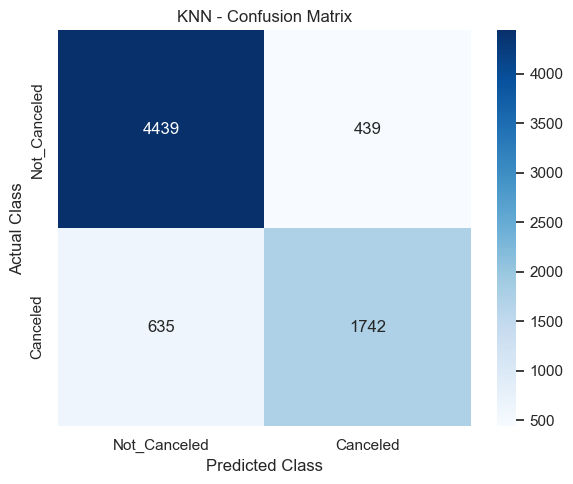

In [43]:
# CONFUSION MATRIX

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not_Canceled", "Canceled"],
    yticklabels=["Not_Canceled", "Canceled"]
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### Observation – K-Nearest Neighbors (KNN)

- The KNN model achieved **85.20% accuracy** and a **weighted F1-score of 85.02%**, showing strong overall classification performance.
- It correctly identified **73.29% of the cancelled bookings**, while achieving a higher recall of **91% for Not_Canceled bookings**.
- The **ROC-AUC of 91.00%** indicates that KNN has a strong ability to distinguish between cancelled and non-cancelled bookings.
- Overall, KNN performed considerably better than the baseline Logistic Regression model.

In [44]:
# STORE KNN RESULTS

results.append({
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "Weighted F1": knn_f1,
    "ROC-AUC": knn_roc_auc
})

print("KNN results added successfully.")

KNN results added successfully.


### KNN Hyperparameter Tuning Curve

The following plot shows how the mean 5-fold cross-validated weighted
F1-score changes with different values of `k`.

The selected value of `k` corresponds to the highest mean
cross-validated weighted F1-score among the tested values.

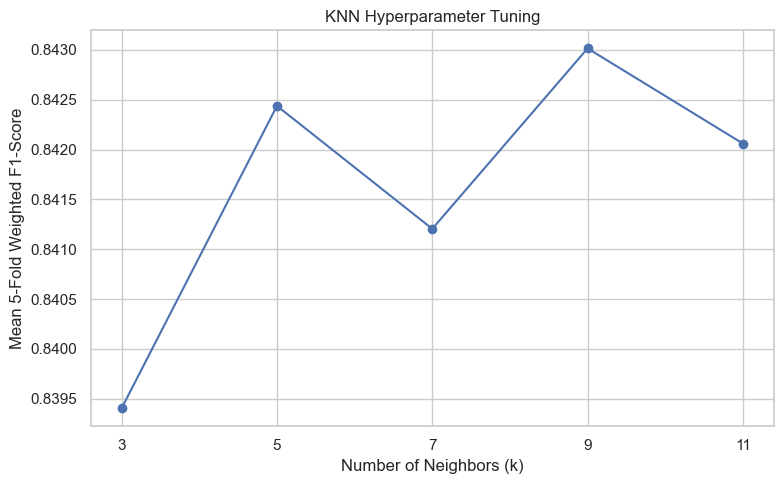

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    knn_cv_results_df["k"],
    knn_cv_results_df["Mean Weighted F1"],
    marker="o"
)

plt.title("KNN Hyperparameter Tuning")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean 5-Fold Weighted F1-Score")
plt.xticks(knn_cv_results_df["k"])
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm based
on Bayes' theorem. It assumes that the features are conditionally
independent given the target class.

For continuous features, Gaussian Naive Bayes assumes that the feature
values within each class follow a Gaussian (normal) distribution.

The conditional-independence assumption may not fully hold for this
hotel booking dataset because some booking-related variables can be
related to each other.

In [46]:
# GAUSSIAN NAIVE BAYES - IMPORTS

from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

In [47]:
# GAUSSIAN NAIVE BAYES MODEL

gnb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", GaussianNB())
    ]
)

gnb_model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


In [48]:
# GNB PREDICTIONS

y_pred_gnb = gnb_model.predict(X_test)
y_proba_gnb = gnb_model.predict_proba(X_test)[:, 1]

print("Gaussian Naive Bayes predictions generated successfully.")

Gaussian Naive Bayes predictions generated successfully.


In [49]:
# GNB EVALUATION METRICS

gnb_accuracy = accuracy_score(y_test, y_pred_gnb)
gnb_precision = precision_score(y_test, y_pred_gnb)
gnb_recall = recall_score(y_test, y_pred_gnb)
gnb_f1 = f1_score(y_test, y_pred_gnb, average="weighted")
gnb_roc_auc = roc_auc_score(y_test, y_proba_gnb)

print(f"Accuracy:           {gnb_accuracy:.4f}")
print(f"Precision:          {gnb_precision:.4f}")
print(f"Recall:             {gnb_recall:.4f}")
print(f"Weighted F1-score:  {gnb_f1:.4f}")
print(f"ROC-AUC:            {gnb_roc_auc:.4f}")

Accuracy:           0.4083
Precision:          0.3522
Recall:             0.9605
Weighted F1-score:  0.3304
ROC-AUC:            0.7881


In [50]:
# GNB CLASSIFICATION REPORT

print("Gaussian Naive Bayes Classification Report")
print("\n")

print(
    classification_report(
        y_test,
        y_pred_gnb,
        target_names=["Not_Canceled", "Canceled"]
    )
)

Gaussian Naive Bayes Classification Report


              precision    recall  f1-score   support

Not_Canceled       0.88      0.14      0.24      4878
    Canceled       0.35      0.96      0.52      2377

    accuracy                           0.41      7255
   macro avg       0.62      0.55      0.38      7255
weighted avg       0.71      0.41      0.33      7255



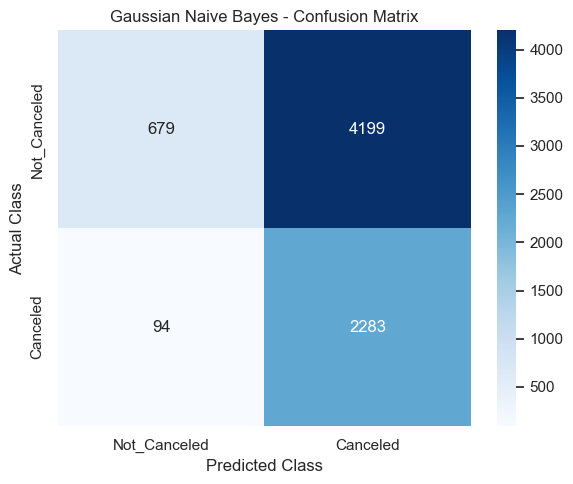

In [51]:
# GNB CONFUSION MATRIX

cm_gnb = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gnb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not_Canceled", "Canceled"],
    yticklabels=["Not_Canceled", "Canceled"]
)

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### Observation – Gaussian Naive Bayes

Gaussian Naive Bayes achieved an accuracy of 40.83% and a weighted
F1-score of 33.04% on the unseen test set. Its ROC-AUC was 78.81%.

The model showed a very high recall of 96.05% for the Canceled class,
meaning that it identified most canceled bookings. However, this came
with a substantial number of false positives: the recall for the
Not_Canceled class was only 14%.

This behavior resulted in relatively low overall accuracy and weighted
F1-score. The results suggest that the conditional-independence and
Gaussian-distribution assumptions of Naive Bayes may not represent the
relationships among the booking features particularly well.

The ROC-AUC of 78.81% indicates that the model's predicted
probabilities retain some ability to distinguish between the two
classes, even though its default class predictions are highly
imbalanced.

In [52]:
# STORING GNB RESULTS

results.append({
    "Model": "Gaussian Naive Bayes",
    "Accuracy": gnb_accuracy,
    "Precision": gnb_precision,
    "Recall": gnb_recall,
    "Weighted F1": gnb_f1,
    "ROC-AUC": gnb_roc_auc
})

print("Gaussian Naive Bayes results added successfully.")

Gaussian Naive Bayes results added successfully.


## 4. Decision Tree Classifier

A Decision Tree Classifier recursively splits the data using feature
values to create increasingly homogeneous groups of observations.

Unlike distance-based models, Decision Trees do not require feature
scaling. The maximum depth of the tree is tuned to control model
complexity. A shallow tree may underfit the data, while an excessively
deep tree may overfit the training data.

For this model, `max_depth` will be tuned using 5-fold cross-validation
on the training data.

In [53]:
# DECISION TREE - IMPORTS

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

In [54]:
# DECISION TREE HYPERPARAMETER TUNING

depth_values = [3, 5, 7, 10, 15, 20]

dt_cv_results = []

for depth in depth_values:

    dt_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            (
                "classifier",
                DecisionTreeClassifier(
                    max_depth=depth,
                    random_state=RANDOM_STATE
                )
            )
        ]
    )

    cv_scores = cross_val_score(
        dt_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )

    dt_cv_results.append({
        "max_depth": depth,
        "Mean Weighted F1": cv_scores.mean(),
        "Std Weighted F1": cv_scores.std()
    })

dt_cv_results_df = pd.DataFrame(dt_cv_results)

display(dt_cv_results_df)

,max_depth,Mean Weighted F1,Std Weighted F1
0,3,0.787196,0.007610
1,5,0.828811,0.007753
2,7,0.848269,0.005690
3,10,0.865671,0.005840
4,15,0.872521,0.004500
5,20,0.864847,0.004113


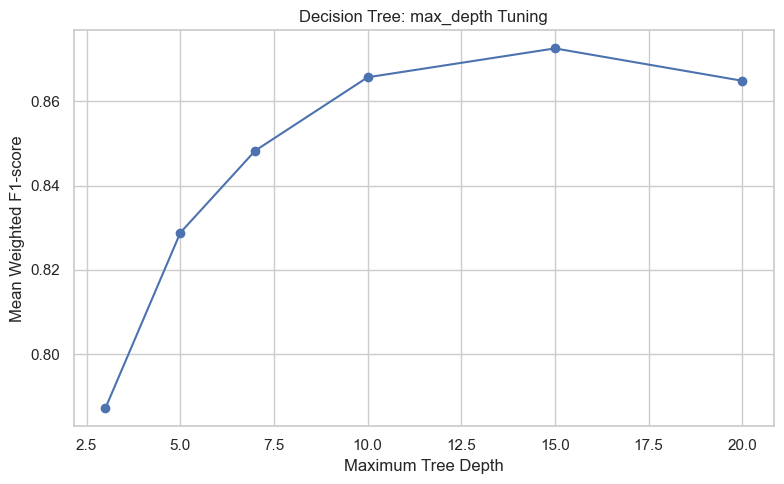

In [55]:
# DECISION TREE TUNING CURVE

plt.figure(figsize=(8, 5))

plt.plot(
    dt_cv_results_df["max_depth"],
    dt_cv_results_df["Mean Weighted F1"],
    marker="o"
)

plt.title("Decision Tree: max_depth Tuning")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Mean Weighted F1-score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
# SELECT BEST max_depth

best_depth = dt_cv_results_df.loc[
    dt_cv_results_df["Mean Weighted F1"].idxmax(),
    "max_depth"
]

best_dt_cv_score = dt_cv_results_df.loc[
    dt_cv_results_df["Mean Weighted F1"].idxmax(),
    "Mean Weighted F1"
]

print("Best max_depth:", int(best_depth))
print(f"Best mean CV Weighted F1: {best_dt_cv_score:.4f}")

Best max_depth: 15
Best mean CV Weighted F1: 0.8725


### Observation – Decision Tree Hyperparameter Tuning

The Decision Tree Classifier was tuned using 5-fold cross-validation
with maximum depths of 3, 5, 7, 10, 15, and 20.

The mean weighted F1-score increased from 0.7872 at max_depth = 3 to
0.8725 at max_depth = 15. At max_depth = 20, the score decreased
slightly to 0.8648. Therefore, max_depth = 15 was selected because it produced the highest
mean cross-validated weighted F1-score of 0.8725 among the tested
values. The relatively small cross-validation standard deviation at
this depth (0.0045) also indicates consistent performance across the
five folds.

In [57]:
# FINAL DECISION TREE MODEL

dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=int(best_depth),
                random_state=RANDOM_STATE
            )
        )
    ]
)

dt_model.fit(X_train, y_train)

print(f"Final Decision Tree trained successfully with max_depth = {int(best_depth)}.")

Final Decision Tree trained successfully with max_depth = 15.


In [58]:
# DECISION TREE PREDICTIONS

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


In [59]:
# DECISION TREE EVALUATION METRICS

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")
dt_roc_auc = roc_auc_score(y_test, y_proba_dt)

print(f"Accuracy:           {dt_accuracy:.4f}")
print(f"Precision:          {dt_precision:.4f}")
print(f"Recall:             {dt_recall:.4f}")
print(f"Weighted F1-score:  {dt_f1:.4f}")
print(f"ROC-AUC:            {dt_roc_auc:.4f}")

Accuracy:           0.8804
Precision:          0.8217
Recall:             0.8107
Weighted F1-score:  0.8801
ROC-AUC:            0.9154


In [60]:
# DECISION TREE CLASSIFICATION REPORT

print("Decision Tree Classification Report")
print("\n")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Not_Canceled", "Canceled"]
    )
)

Decision Tree Classification Report


              precision    recall  f1-score   support

Not_Canceled       0.91      0.91      0.91      4878
    Canceled       0.82      0.81      0.82      2377

    accuracy                           0.88      7255
   macro avg       0.87      0.86      0.86      7255
weighted avg       0.88      0.88      0.88      7255



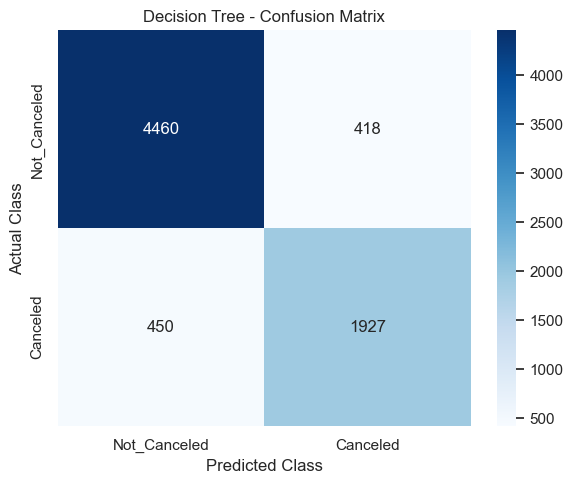

In [61]:
# DECISION TREE CONFUSION MATRIX

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not_Canceled", "Canceled"],
    yticklabels=["Not_Canceled", "Canceled"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### Observation – Decision Tree Classifier

The Decision Tree Classifier achieved an **accuracy of 88.04%** and a
**weighted F1-score of 88.01%** on the unseen test set. The model also
achieved a **ROC-AUC of 91.54%**, indicating strong discriminatory
ability between canceled and non-canceled bookings.

The classification report shows relatively balanced performance across
the two classes. For `Not_Canceled`, the model achieved a precision and
recall of **0.91**. For `Canceled`, it achieved a precision of **0.82**
and recall of **0.81**, showing that the model was able to identify a
substantial proportion of canceled bookings while maintaining a
moderate false-positive rate.

The selected `max_depth = 15` was obtained through 5-fold
cross-validation and produced the highest mean weighted F1-score
(**0.8725**) among the tested depths. The test-set results therefore
demonstrate that the tuned Decision Tree generalizes well to the
unseen test data.

Overall, the Decision Tree provides a strong non-linear model for this
dataset and captures feature interactions that may not be adequately
represented by simpler linear or probabilistic models.

In [62]:
# STORE DECISION TREE RESULTS

results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "Weighted F1": dt_f1,
    "ROC-AUC": dt_roc_auc
})

print("Decision Tree results added successfully.")

Decision Tree results added successfully.


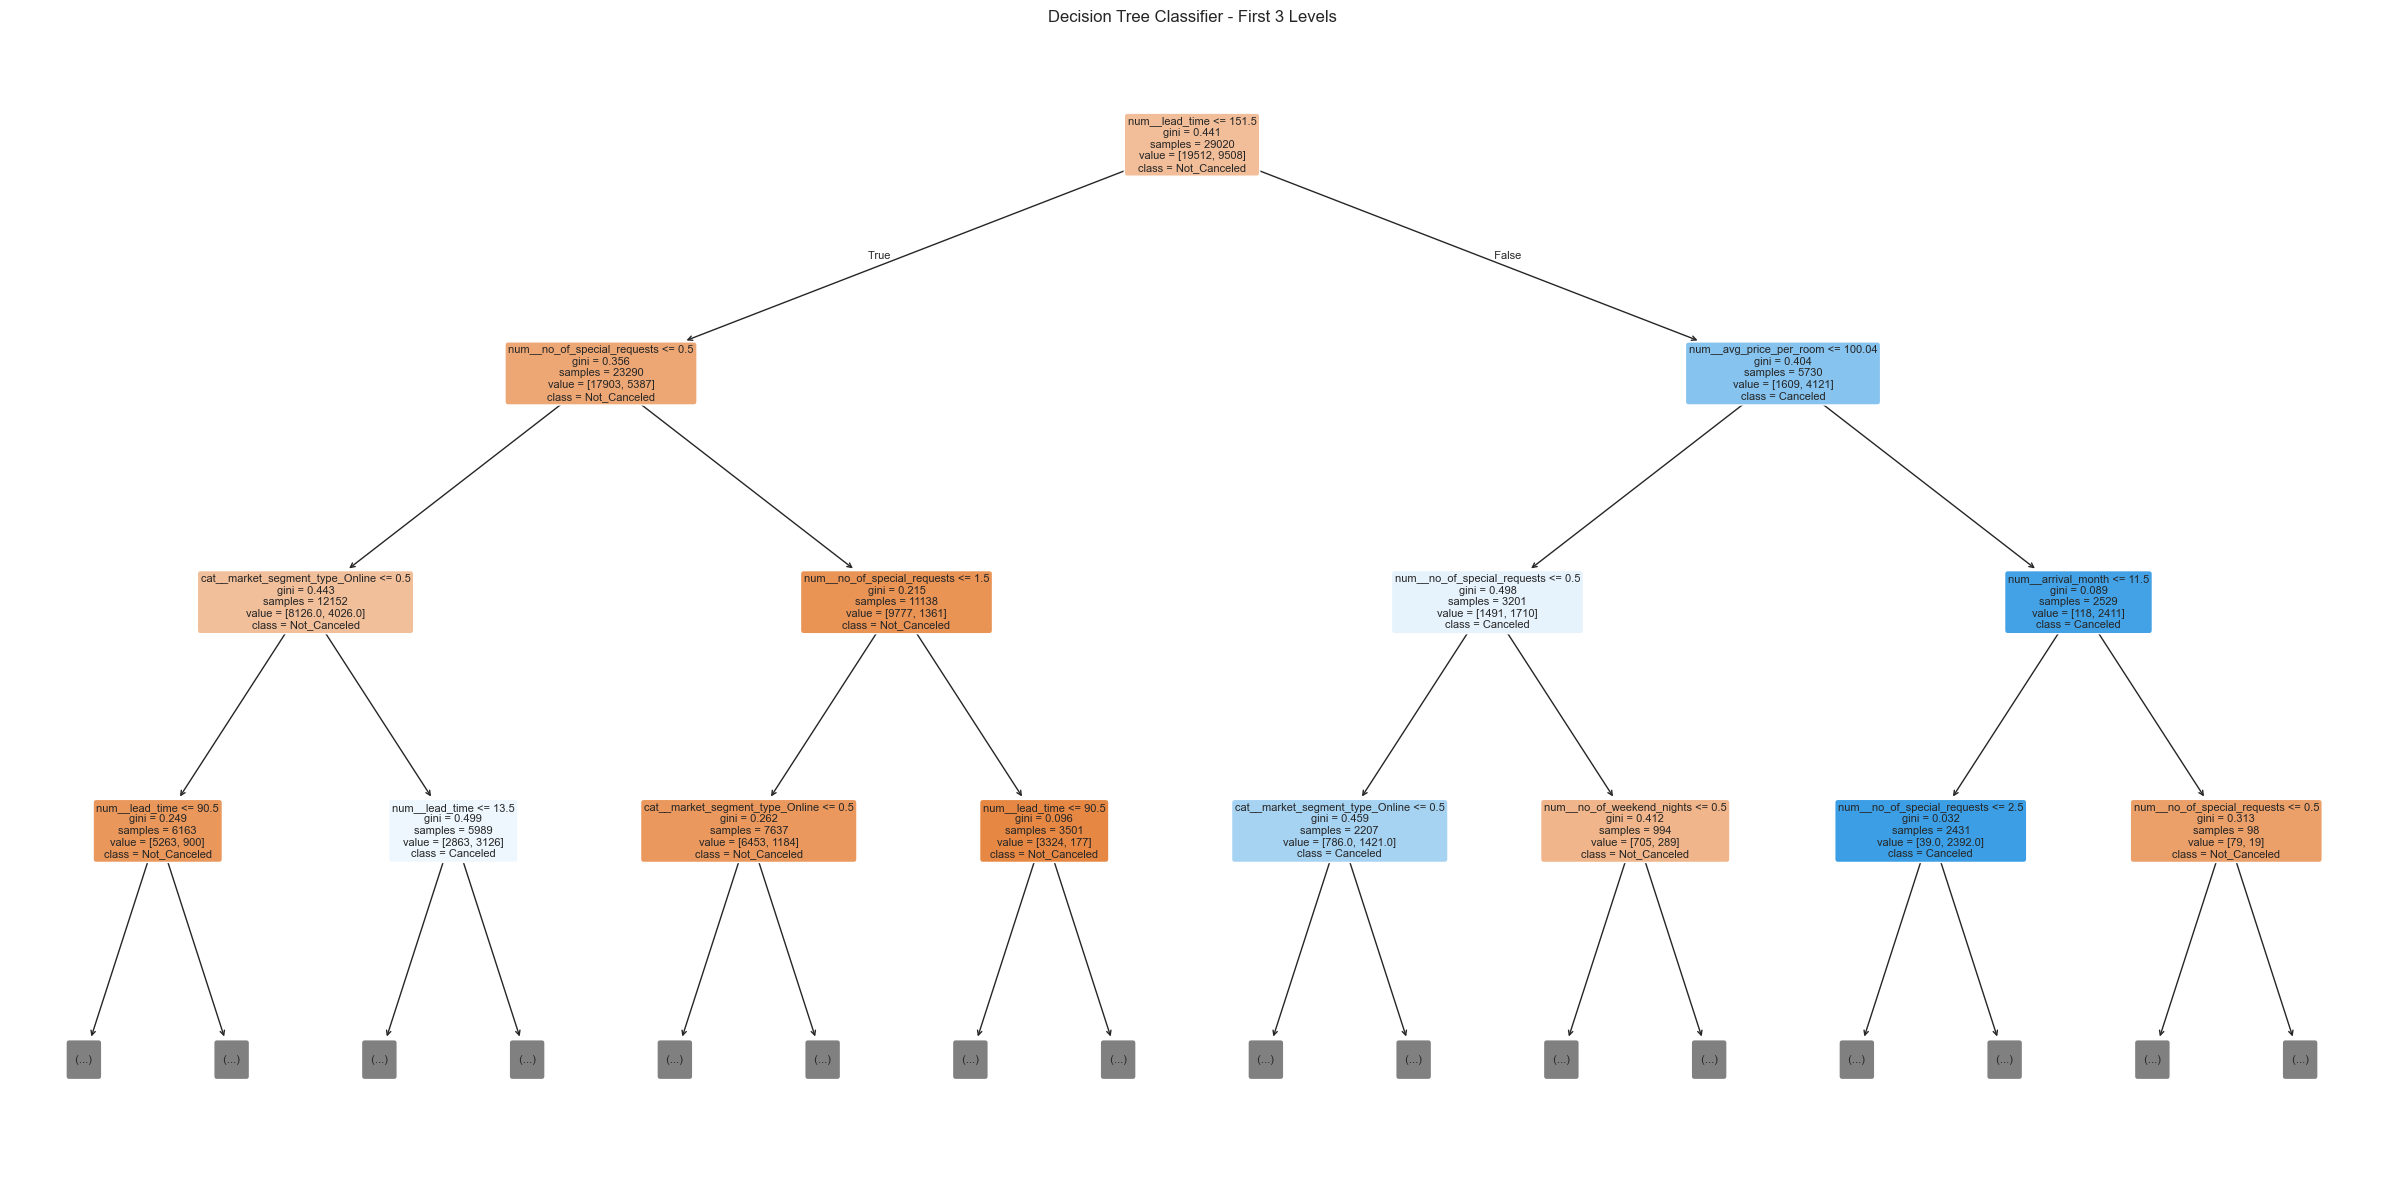

In [63]:
# DECISION TREE VISUALIZATION

from sklearn.tree import plot_tree

# Get the fitted preprocessor and classifier
fitted_dt_preprocessor = dt_model.named_steps["preprocessor"]
fitted_dt_classifier = dt_model.named_steps["classifier"]

# Get feature names after preprocessing
dt_feature_names = fitted_dt_preprocessor.get_feature_names_out()

plt.figure(figsize=(24, 12))

plot_tree(
    fitted_dt_classifier,
    feature_names=dt_feature_names,
    class_names=["Not_Canceled", "Canceled"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Classifier - First 3 Levels")
plt.tight_layout()
plt.show()

## 5. Support Vector Classifier (SVC)

Support Vector Classifier (SVC) is a supervised classification
algorithm that identifies a decision boundary that separates classes
while maximizing the margin between them.

The regularization parameter `C` controls the trade-off between
maximizing the margin and minimizing classification errors. A smaller
C allows a wider margin with more tolerance for misclassification,
while a larger C places greater emphasis on correctly classifying
training observations.

The kernel determines how the input features are transformed to
construct the decision boundary. Linear and RBF kernels are evaluated
during tuning.

Since SVC is sensitive to feature scale, numerical features are
standardized during preprocessing. Hyperparameter tuning is performed
using 5-fold cross-validation on the training data only.

In [64]:
# SVC - IMPORTS

from sklearn.svm import SVC

In [65]:
# ==========================================
# SVC HYPERPARAMETER TUNING
# ==========================================

C_values = [0.1, 1, 10]
kernel_values = ["linear", "rbf"]

svc_cv_results = []

for C in C_values:
    for kernel in kernel_values:

        print(f"Testing C={C}, kernel={kernel}...")

        svc_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor_scaled),
                (
                    "classifier",
                    SVC(
                        C=C,
                        kernel=kernel,
                        random_state=RANDOM_STATE
                    )
                )
            ]
        )

        cv_scores = cross_val_score(
            svc_pipeline,
            X_train,
            y_train,
            cv=5,
            scoring="f1_weighted",
            n_jobs=-1
        )

        svc_cv_results.append({
            "C": C,
            "Kernel": kernel,
            "Mean Weighted F1": cv_scores.mean(),
            "Std Weighted F1": cv_scores.std()
        })

svc_cv_results_df = pd.DataFrame(svc_cv_results)

display(svc_cv_results_df)

Testing C=0.1, kernel=linear...
Testing C=0.1, kernel=rbf...
Testing C=1, kernel=linear...
Testing C=1, kernel=rbf...
Testing C=10, kernel=linear...
Testing C=10, kernel=rbf...


,C,Kernel,Mean Weighted F1,Std Weighted F1
0,0.1,linear,0.794828,0.003672
1,0.1,rbf,0.818624,0.004637
2,1.0,linear,0.794947,0.003286
3,1.0,rbf,0.840463,0.005472
4,10.0,linear,0.794875,0.003432
5,10.0,rbf,0.854761,0.006437


### Observation – SVC Hyperparameter Tuning

The Support Vector Classifier was tuned using 5-fold cross-validation
with C values of 0.1, 1, and 10, using both linear and RBF kernels.

The RBF kernel consistently achieved higher mean weighted F1-scores
than the linear kernel across all tested values of C. For the RBF
kernel, the mean weighted F1-score increased from 0.8186 at C = 0.1
to 0.8405 at C = 1 and 0.8548 at C = 10.

The highest mean cross-validated weighted F1-score of 0.8548 was
obtained with C = 10 and the RBF kernel.

The results indicate that, the
non-linear RBF kernel captured the classification patterns better than
the linear kernel. Feature scaling was applied during preprocessing
because SVC is sensitive to the relative scale of numerical features.

In [66]:
# Best hyperparameters obtained from SVC tuning
best_svc_row = svc_cv_results_df.loc[
    svc_cv_results_df["Mean Weighted F1"].idxmax()
]

best_C = best_svc_row["C"]
best_kernel = best_svc_row["Kernel"]

print("Best SVC parameters:")
print("C =", best_C)
print("Kernel =", best_kernel)
print(
    "Best mean CV weighted F1 =",
    round(best_svc_row["Mean Weighted F1"], 4)
)

Best SVC parameters:
C = 10.0
Kernel = rbf
Best mean CV weighted F1 = 0.8548


In [ ]:
# FINAL SVC MODEL

svc_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_scaled),
        (
            "classifier",
            SVC(
                C=best_C,
                kernel=best_kernel,
                probability=True,
                random_state=RANDOM_STATE
            )
        )
    ]
)

svc_model.fit(X_train, y_train)

print(
    f"Final SVC trained successfully with "
    f"C = {best_C} and kernel = '{best_kernel}'."
)

In [ ]:
# SVC PREDICTIONS

y_pred_svc = svc_model.predict(X_test)
y_proba_svc = svc_model.predict_proba(X_test)[:, 1]

print("SVC predictions generated successfully.")

In [ ]:
# SVC EVALUATION METRICS

svc_accuracy = accuracy_score(y_test, y_pred_svc)
svc_precision = precision_score(y_test, y_pred_svc)
svc_recall = recall_score(y_test, y_pred_svc)
svc_f1 = f1_score(y_test, y_pred_svc, average="weighted")
svc_roc_auc = roc_auc_score(y_test, y_proba_svc)

print(f"Accuracy:           {svc_accuracy:.4f}")
print(f"Precision:          {svc_precision:.4f}")
print(f"Recall:             {svc_recall:.4f}")
print(f"Weighted F1-score:  {svc_f1:.4f}")
print(f"ROC-AUC:            {svc_roc_auc:.4f}")

In [ ]:
# SVC CLASSIFICATION REPORT

print("SVC Classification Report")
print("\n")

print(
    classification_report(
        y_test,
        y_pred_svc,
        target_names=["Not_Canceled", "Canceled"]
    )
)

In [ ]:
# SVC CONFUSION MATRIX

cm_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not_Canceled", "Canceled"],
    yticklabels=["Not_Canceled", "Canceled"]
)

plt.title("SVC - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### Observation – Support Vector Classifier (SVC)

The Support Vector Classifier achieved an **accuracy of 86.38%** and a
**weighted F1-score of 86.24%** on the unseen test set. The model also
achieved a **ROC-AUC of 92.43%**, indicating strong discriminatory
ability between canceled and non-canceled bookings.

The classification report shows that the model performed better on the
`Not_Canceled` class, with a precision of **0.88** and recall of
**0.92**. For the `Canceled` class, the model achieved a precision of
**0.82** and recall of **0.76**. This indicates that the model correctly
identifies a substantial proportion of canceled bookings, although some
canceled bookings are still classified as non-canceled.

The SVC was tuned using 5-fold cross-validation over different values of
C and kernel types. The best configuration among the tested settings
was **C = 10 with an RBF kernel**, which achieved a mean weighted
F1-score of **0.8548** during cross-validation.

Feature scaling was applied because SVC is sensitive to the scale of
numerical features. The RBF kernel allows the model to capture
non-linear relationships between the booking features.

Overall, the SVC provides strong classification performance, particularly
in terms of ROC-AUC, while maintaining reasonably balanced performance
between the two target classes.

In [ ]:
# Storing final SVC results

results.append({
    "Model": "SVC",
    "Accuracy": svc_accuracy,
    "Precision": svc_precision,
    "Recall": svc_recall,
    "Weighted F1": svc_f1,
    "ROC-AUC": svc_roc_auc
})

In [ ]:
# CONSOLIDATED MODEL COMPARISON

results_df = pd.DataFrame(results)

display(results_df.round(4))

## Preliminary Model Comparison

The five classification algorithms were evaluated on the same unseen
stratified test set using Accuracy, Precision, Recall, Weighted
F1-score, and ROC-AUC.

The comparison provides an overall view of how the different
classification approaches perform on the hotel booking cancellation
prediction problem.

In [ ]:
# MODEL COMPARISON TABLE

comparison_df = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "Weighted F1",
    "ROC-AUC"
]

comparison_df[metric_columns] = comparison_df[metric_columns] * 100

display(comparison_df.round(2))

### Model Performance Comparison

The following visualization compares the five classification models
across Accuracy, Weighted F1-score, and ROC-AUC. These metrics provide
a compact view of overall classification performance and the models'
ability to distinguish between the two booking-status classes.

In [ ]:
# MODEL PERFORMANCE COMPARISON

plot_df = results_df.set_index("Model")[
    ["Accuracy", "Weighted F1", "ROC-AUC"]
] * 100

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6),
    color=["#0072B2", "#E69F00", "#009E73"]
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Score (%)")
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Preliminary Comparison – Observations

The five models show noticeable differences in classification
performance.

Logistic Regression achieved an accuracy of **81.28%** and a weighted
F1-score of **80.86%**, providing a useful linear baseline. Its
ROC-AUC of **87.16%** indicates that the model has reasonable
discriminatory ability.

KNN achieved an accuracy of **85.20%** and a weighted F1-score of
**85.02%**, with a ROC-AUC of **91.00%**. The model therefore provided
an improvement over the Logistic Regression baseline on the evaluated
test metrics.

Gaussian Naive Bayes produced a substantially different performance
profile. Although it achieved a high recall of **96.05%** for the
`Canceled` class, its overall accuracy was **40.83%** and its weighted
F1-score was **33.04%**. This indicates that the model generated a
large number of incorrect predictions for the `Not_Canceled` class.

The Decision Tree achieved an accuracy of **88.04%**, weighted F1-score
of **88.01%**, and ROC-AUC of **91.54%**. Its class-wise precision and
recall were relatively balanced compared with the other models.

SVC achieved an accuracy of **86.38%** and a weighted F1-score of
**86.24%**. It produced the highest ROC-AUC among the five evaluated
models at **92.43%**, indicating strong ranking/discriminatory
performance on the test set.

The results demonstrate that model performance depends on the
algorithm and its assumptions. The Decision Tree and SVC provided
strong overall results, while Gaussian Naive Bayes showed a different
precision-recall trade-off for the two classes.

Cross-validation was also performed during hyperparameter tuning for
KNN, Decision Tree, and SVC, providing additional training-set
evidence for selecting their respective hyperparameters.

## Part A – Final Summary

This notebook developed an end-to-end classification pipeline for predicting
hotel booking cancellation using the INN Hotels Group booking dataset.

The dataset was first audited for dimensions, data types, missing values,
duplicates, class distribution, and feature cardinality. Exploratory Data
Analysis was then performed using target-distribution plots, numerical and
categorical feature distributions, correlation analysis, scatter plots, and
boxplots.

Potential outliers were investigated using the IQR method. Instead of
removing potentially valid hotel booking observations, IQR capping was
applied to selected continuous features. The capping thresholds were
calculated using the training data only and then applied consistently to
the training and testing sets.

Feature engineering was performed by creating total nights, total guests,
total previous bookings, a family indicator, price per guest, and cyclic
representations of arrival month. These features provide additional
representations of booking characteristics that may help the classification
models identify useful patterns.

Categorical variables were one-hot encoded, while numerical variables were
appropriately imputed and scaled for algorithms that are sensitive to
feature magnitude. A stratified 80:20 train-test split with
`random_state = 42` was used consistently across all five algorithms.

Five Part-A classification algorithms were implemented:

1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier

Hyperparameter tuning was performed using 5-fold cross-validation on the
training data for KNN, Decision Tree, and SVC. The test set was kept
separate during model selection.

The final models were evaluated using Accuracy, Precision, Recall, Weighted
F1-score, ROC-AUC, and Confusion Matrix. The results show that the
classification algorithms exhibit different performance characteristics,
reflecting their different modelling assumptions and decision mechanisms.

The Part-A results provide a baseline for the next stage of the
classification track, where additional classification algorithms will be
evaluated and compared using the same dataset and evaluation framework.